Write your solution in here.

- Your code has to reference all data files using **relative** paths so that they can be loaded on other computers without modifications.
- All data files need to be stored in the `data/` folder.

For example: (REMOVE THIS)

In [375]:
import pandas as pd

# Define the path to the data directory
DATA_PATH = './data'

# Read the CSV using a relative path
df = pd.read_csv(f'{DATA_PATH}/sce_extract_2015.csv')

In [376]:
import time
start_time = time.time()

# Term Paper 2 - Expectations about Macroeconomic and Financial Variables

### Initial Setup - Modules, Display options, Data Path

In [377]:
# Modules
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
# Scikit-learn modules for regression and evaluation
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import ColumnTransformer
# For correlation tables
from IPython.display import display, HTML


# Set display options for better readability
pd.set_option('display.max_columns', 50)

# Set plot style for consistent and visually appealing graphs
plt.style.use('seaborn-v0_8-whitegrid')

# Define the path to the data directory
DATA_PATH = './data'

## Part 1 - Data Preprocessing (SCE)

### 1.1 - Load SCE and Report Initial Sample Characteristics

In [378]:
def load_sce(DATA_PATH: str, file):
    """Load and concatenate SCE CSV files, keeping only relevant columns and parsing dates."""
    # Define columns to read from the CSV files
    # Columns with variables only reported in the first wave of the survey
    COLS_FIRST_WAVE = ['owner','num_lit_q1_correct', 'num_lit_q2_correct', 'num_lit_q3_correct', 'num_lit_q5_correct', 'num_lit_q6_correct']
    # Columns with metadata
    COLS_META = ['userid', 'wid', 'date', 'tenure']
    # Columns with expectation-variables (Targets for modelling later)
    COLS_EXPECTATIONS = ['infl_1y', 'house_price_change', 'prob_unrate_up', 'prob_stocks_up']
    # Columns with individual characteristics
    COLS_INDIVIDUAL = ['female', 'hispanic', 'black', 'educ', 'hh_inc_bin_rank', 'working', 'couple', 'num_kids', 'age_init']
    # Combine all columns for analysis
    ANALYSIS_COLS = COLS_FIRST_WAVE + COLS_EXPECTATIONS + COLS_INDIVIDUAL
    # Combine all columns to read from the CSV files
    ALL_COLS  = COLS_META + ANALYSIS_COLS

    # Read and concatenate all CSV files, keeping only the relevant columns and parsing dates
    files = sorted(glob.glob(f'{DATA_PATH}/sce_extract_*.csv'))
    sce = pd.concat(
        (pd.read_csv(file, usecols=ALL_COLS, parse_dates=['date']) for file in files),
        ignore_index=True
    )
    return COLS_FIRST_WAVE, COLS_META, COLS_EXPECTATIONS, COLS_INDIVIDUAL, ANALYSIS_COLS, ALL_COLS, sce

In [379]:
# Load SCE data and store Columns in variables for later use
COLS_FIRST_WAVE, COLS_META, COLS_EXPECTATIONS, COLS_INDIVIDUAL, ANALYSIS_COLS, ALL_COLS, sce = load_sce(DATA_PATH, file=f'{DATA_PATH}/sce_extract_2015.csv')

# Number of observations, individuals, and survey waves in the initial dataset
n_obs_init   = len(sce)
n_ind_init   = sce['userid'].nunique()
n_waves_init = sce['wid'].nunique()

first_date_init = sce['date'].min().date()
last_date_init  = sce['date'].max().date()

# Print initial data summary
print("=== Initial sample ===")
print(f"  Observations : {n_obs_init:,}")
print(f"  Individuals  : {n_ind_init:,}")
print(f"  Survey waves : {n_waves_init}")
print(f"  Date range   : {first_date_init} → {last_date_init}")

=== Initial sample ===
  Observations : 180,268
  Individuals  : 23,886
  Survey waves : 143
  Date range   : 2013-06-01 → 2025-05-01


The individual-level features were selected based on two criteria: economic relevance as predictors of expectations, and data availability. Several variables were excluded due to a high share of missing values (20% or more), which would have substantially reduced the sample size: num_lit_q8_correct, num_lit_q9_correct, take_fin_risk, health, and self_employed. The survey sampling weight was dropped since not all scikit-learn estimators support sample weights.
Variables asked only at the first interview (owner, age_init, and the numerical literacy indicators) are forward-filled within each individual so that later waves carry the value from the first wave. Other expectation-related variables (e.g. infl_3y, prob_irate_up) are excluded as predictors, since they would not be available to a policymaker trying to forecast expectations in real time.

age_init was recorded at first interview, but carried forward prior to our analysis, hence why it's not in COLS_FIRST_WAVE. 

### 1.2 - Forward-fill First Wave Variables Within Each Individual

In [380]:
# Step 2 - Forward-fill within each individual (only fills NaNs after the first observed value)
sce[COLS_FIRST_WAVE] = (
    sce.groupby('userid')[COLS_FIRST_WAVE].ffill()
)

### 1.3 - Drop 2025 Observations to avoid Trump-Volatility

In [381]:
# Step 3 - Drop observations from 2025 due to Trump-volatility
mask_2025 = sce['date'].dt.year == 2025
n_dropped_2025 = mask_2025.sum()
sce = sce[~mask_2025].copy()
print(f"Step 3 — Dropped {n_dropped_2025:,} observations from 2025")

Step 3 — Dropped 4,167 observations from 2025


### 1.4 - Drop Missing Values in Analysis Columns

In [382]:
# Step 4 - Drop observations with missing values in the analysis columns
n_before = len(sce)
sce = sce.dropna(subset=ANALYSIS_COLS).copy()
print(f"Step 4 — Dropped {n_before - len(sce):,} observations with missing values")

Step 4 — Dropped 16,966 observations with missing values


### 1.5 - Trim outliers in Expectations Columns (Targets) at 1st and 99th Percentiles

## CONSIDER MASK AS TRIMMING METHOD HERE

In [383]:
# Step 5 - Trim outliers in expectation columns by capping values at the 1st and 99th percentiles
def trim_outliers(df, cols):
    """Trim outliers in specified columns by capping values at the 1st and 99th percentiles."""
    # Find percentiles for each column
    percentiles = {col: (df[col].quantile(0.01), df[col].quantile(0.99)) for col in cols}
    
    # Store the original number of observations before trimming
    obs_dropped = 0
    # Trim outliers for each column
    for col in cols:
        p1, p99 = percentiles[col]
        before = len(df)
        df = df[(df[col] > p1) & (df[col] < p99)]
        obs_dropped += before - len(df)
        print(f'  Trimmed {before - len(df):,} observations in column "{col}" outside [{p1:.2f}, {p99:.2f}]')

    # Final summary of outliers dropped
    print('-'*50)
    print(f"Step 5 — Dropped {obs_dropped:,} observations as outliers")
    
    return df

In [384]:
# Trim outliers in expectation columns
sce = trim_outliers(sce, COLS_EXPECTATIONS)

  Trimmed 3,400 observations in column "infl_1y" outside [-30.00, 60.00]
  Trimmed 3,790 observations in column "house_price_change" outside [-20.00, 50.00]
  Trimmed 4,034 observations in column "prob_unrate_up" outside [0.00, 100.00]
  Trimmed 2,394 observations in column "prob_stocks_up" outside [0.00, 95.00]
--------------------------------------------------
Step 5 — Dropped 13,618 observations as outliers


For prob_unrate_up, the 1st percentile is 0 and the 99th percentile is 100. Since the trimming condition is strictly > P1 and < P99, observations with values exactly equal to 0 or 100 are dropped. These are respondents who are completely certain about the direction of unemployment, which are valid responses rather than data errors - however, we follow the assignment instructions and apply the same rule to all four variables.
For prob_stocks_up, P99 = 95, meaning the top 1% of responses (above 95%) are removed as extreme outliers.

### 1.6 - Create Optimism Indicators

In [385]:
# Step 6 - Create Optimism indicators
sce['optimist_unrate']      = (sce['prob_unrate_up'] < 50).astype(int)
sce['optimist_stocks']      = (sce['prob_stocks_up'] > 50).astype(int)
sce['optimist_house_price'] = (sce['house_price_change'] > 0).astype(int)

# Store optimism indicators in a list for later use
OPTIMISM_COLS = ['optimist_unrate', 'optimist_stocks', 'optimist_house_price']

ALL_COLS += OPTIMISM_COLS

### End Part 1: Display Initial and Final Sample Information

In [386]:
# Data cleaning summary
summary = pd.DataFrame({
    'Sample'       : ['Initial', 'Final', 'Difference'],
    'Observations' : [n_obs_init, len(sce), len(sce) - n_obs_init],
    'Individuals'  : [n_ind_init, sce['userid'].nunique(), sce['userid'].nunique() - n_ind_init],
    'Survey waves' : [n_waves_init, sce['wid'].nunique(), sce['wid'].nunique() - n_waves_init],
    'First date'   : [first_date_init, sce['date'].min().date(), 'No Change'],
    'Last date'    : [last_date_init, sce['date'].max().date(), f'{(sce["date"].max().date() - last_date_init).days} days'],
})
display(summary)

,Sample,Observations,Individuals,Survey waves,First date,Last date
0,Initial,180268,23886,143,2013-06-01,2025-05-01
1,Final,145517,21783,139,2013-06-01,2024-12-31
2,Difference,-34751,-2103,-4,No Change,-121 days


The final sample of $145,517$ observations is close to the target of ~$150,000$. Comment individuals and dates ... ...

## Part 2 - Data Preprocessing (Macro/Finance)

All macro and financial time series are downloaded and saved as CSV files in the "data" folder. **Yahoo Finance** data was downloaded programmatically using yfinance, while **FRED** data was downloaded manually from fred.stlouisfed.org. All series are resampled to monthly frequency. To avoid look-ahead bias, each series is shifted forward by one month so that a respondent interviewed in month $t$ only sees data available through the end of month $t−1$. For quarterly series (GDP, House Price Index), values are forward-filled within the quarter.

Additionally, we added two series not mentioned in the assignment - CBOE Volatility Index (VIX) and US 10-year treasury yield. 
- VIX captures uncertainty directly, which could be relevant for prob_stocks_up and general economic expectations.  
- The 10-year treasury yield as the long end of the yield curve embeds market participants' inflation and growth expectations, making it a good candidate for modelling infl_1y. 

Variables are included both in levels and as changes:

- Levels capture the current macroeconomic environment (e.g., high unemployment may anchor pessimism about future unemployment).
- 12-month changes capture recent momentum and surprises (e.g., a sharp rise in CPI may push inflation expectations higher regardless of the level).
- 1-month changes are computed for monthly series only and capture short-run surprises.
- VIX is kept only in levels since it is already a measure of reltive uncertainty. Percentage changes would be harder to interpret economically. 

For series expressed as index or price levels (CPI, House Price Index, Real GDP, USD Index, WTI Crude Oil, S&P 500), changes are expressed as percentage growth rates, since a one-unit absolute difference is not economically meaningful. For series already expressed in percentage terms (Federal Funds Rate, Unemployment Rate, 30-Year Mortgage Rate), changes are expressed as percentage-point differences, since a relative change (e.g. "the fed funds rate doubled") would be misleading when the level is near zero.
The final selection of which transformations to use as predictors is deferred to Parts 5 and 6, guided by the correlation analysis in Part 4.

In [387]:
def load_yahoo(data_path: str) -> pd.DataFrame:
    """Load yahoo finance data from CSV files, resample to monthly frequency, and compute changes."""
    # Define the mapping of column names to their corresponding CSV filenames
    files = {
        'wti_crude_oil': 'wti_crude_oil.csv',
        'sp500':         'sp500.csv',
    }

    monthly = []
    for col, filename in files.items():
        df = pd.read_csv(f'{data_path}/{filename}', parse_dates=['date'], index_col='date')
        print(f'Loaded {col} with {len(df):,} observations from {df.index.min().date()} to {df.index.max().date()}')

        m = df.resample('ME').last()
        m[f'{col}_chg']     = m[col].pct_change()
        m[f'{col}_chg_12m'] = m[col].pct_change(12)
        monthly.append(m.shift(1))

    # COncatenate all processed series
    out = pd.concat(monthly, axis=1)
    # Shift all series by one month to avoid look-ahead bias and sort by index
    out = out.shift(1).sort_index()
    # Limit date range to match the SCE data
    out = out[(out.index >= sce['date'].min()) & (out.index <= sce['date'].max())]

    return out

In [388]:
# Load Yahoo Finance data
yahoo = load_yahoo(DATA_PATH)

Loaded wti_crude_oil with 3,772 observations from 2010-01-04 to 2024-12-31
Loaded sp500 with 3,774 observations from 2010-01-04 to 2024-12-31


Yahoo Finance series are loaded and merged, with 1-month and 12-month change calculations performed, and observations shifted by a month.

Note that date range is not limited to SCE data at this point, and with the data starting in January 2010 all returns variables have some NA's. After merging with macro and SCE, there will be none. 

In [389]:
# Reusable function to load and preprocess FRED data based on the configuration
def load_fred(data_path: str, config: dict) -> pd.DataFrame:
    """
    Load, resample, compute changes, and shift FRED series to monthly frequency.

    Parameters:
        data_path: Path to the directory containing the FRED CSV files.
        config: Configuration dictionary specifying the series to load and their processing instructions.
    """
    # Dictionary to hold the processed series
    series = {}
    # Load, resample, compute changes, and shift each series according to the configuration
    for name, (fname, is_quarterly, chg_fn) in config.items():
        # Load the CSV file for the series
        s = pd.read_csv(
            f"{data_path}/{fname}",
            parse_dates=[0], index_col=0,
            header=0, names=["date", name],
        )
        # If the series is quarterly, adjust the index to represent the end of the quarter
        if is_quarterly:
            s.index = s.index + pd.offsets.QuarterEnd(0)
        s_m = s.resample("ME").last()
        if is_quarterly:
            s_m = s_m.ffill()

        # Compute changes based on the specified change function
        if chg_fn == "pct":
            s_m[f"{name}_chg12m"] = s_m[name].pct_change(12, fill_method=None) * 100
            if not is_quarterly:
                s_m[f"{name}_chg1m"] = s_m[name].pct_change(1, fill_method=None) * 100
        elif chg_fn == "diff":
            s_m[f"{name}_chg12m"] = s_m[name].diff(12)
            if not is_quarterly:
                s_m[f"{name}_chg1m"] = s_m[name].diff(1)
        elif chg_fn is not None:
            raise ValueError(f"Unknown change type {chg_fn!r} for series {name!r}")
        
        # Store the processed series in the dictionary
        series[name] = s_m

    # Concatenate all processed series
    out = pd.concat(series.values(), axis=1)
    # Shift all series by one month to avoid look-ahead bias and sort by index
    out = out.shift(1).sort_index()
    # Limit date range to match the SCE data
    out = out[(out.index >= sce['date'].min()) & (out.index <= sce['date'].max())]

    return out

In [390]:
# Configuration: name -> (filename, is_quarterly, change_type)
# pct: price/index series — changes as % growth rates
# diff: series already in % terms — changes as percentage-point differences
# None: no change computed for VIX
FRED_CONFIG = {
    "cpi":              ("CPIAUCSL.csv",     False, "pct"),
    "house_price_idx":  ("USSTHPI.csv",      True,  "pct"),
    "federal_funds":    ("FEDFUNDS.csv",     False, "diff"),
    "unemployment":     ("UNRATE.csv",       False, "diff"),
    "real_gdp":         ("GDPC1.csv",        True,  "pct"),
    "usd_index":        ("DTWEXBGS.csv",     False, "pct"),
    "mortgage_30y":     ("MORTGAGE30US.csv", False, "diff"),
    "10y_yield":        ("DGS10.csv",        False, "diff"),
    "vix":              ("VIXCLS.csv",       False, None),
}

# Load FRED data
fred = load_fred(DATA_PATH, FRED_CONFIG)

Macro data sets are loaded and merged, with 1-month and 12-month changes calculated for all variables (except VIX).

In [391]:
# Reusable function to merge yahoo, FRED, and SCE data on a monthly basis
def merge_all(sce: pd.DataFrame, yahoo: pd.DataFrame, fred: pd.DataFrame):
    """Merge SCE, Yahoo Finance, and FRED data on a monthly basis."""
    # Merge Yahoo Finance data into the monthly macro panel (Combine in reusable function for loading and processing FRED/Yahoo data?)
    macro_all = fred.join(yahoo, how="left")
    macro_all = macro_all.sort_index()

    # Prepare macro_all for merging: reset date index into a column named 'date_me'
    macro_for_merge = macro_all.rename_axis('date_me').reset_index()

    # Prepare SCE data for merging: create a month-end date key (date_me) that maps each interview date to the corresponding month-end
    sce['date_me'] = sce['date'] + pd.offsets.MonthEnd(0)

    # Left-join SCE with macro panel, then drop the temporary merge key
    sce_data = sce.merge(macro_for_merge, on='date_me', how='left').drop(columns=['date_me'])

    # Store the list of macro/finance columns for later use (all columns that are not in the previously defined set)
    MACRO_COLS = [
        c for c in sce_data.columns
        if c not in set(ALL_COLS) 
    ]
    
    # Update ALL_COLS to include the new macro/finance columns
    ALL_COLS.extend(MACRO_COLS)

    # Returns the merged dataset along with the updated column lists
    return sce_data, macro_all, MACRO_COLS, ALL_COLS

In [392]:
# Merge all datasets into a single DataFrame for analysis, store new columns and updated column list for later use
sce_data, macro_all, MACRO_COLS, ALL_COLS = merge_all(sce, yahoo, fred)

All macroeconomic and finance data merged with SCE, limited to SCE date range and shifted by a month to reflect real time information. 

## Part 3 - Exploratory Data Analysis (SCE)

In [393]:
# Plot prep: create lists of (column, title) pairs for plotting
exp_labels = [
    'Inflation Expectations (1 Year)',
    'House Price Change Expectations',
    'Unemployment Rate Increase Probability',
    'Stock Market Increase Probability',
]
exp_plot_vars = list(zip(COLS_EXPECTATIONS, exp_labels))

# Optimism indicators labels
opt_titles = [
    'Unemployment Optimists (prob < 50%)',
    'Stock Market Optimists (prob > 50%)',
    'House Price Optimists (change > 0%)'
]

opt_plot_vars = list(zip(OPTIMISM_COLS, opt_titles))

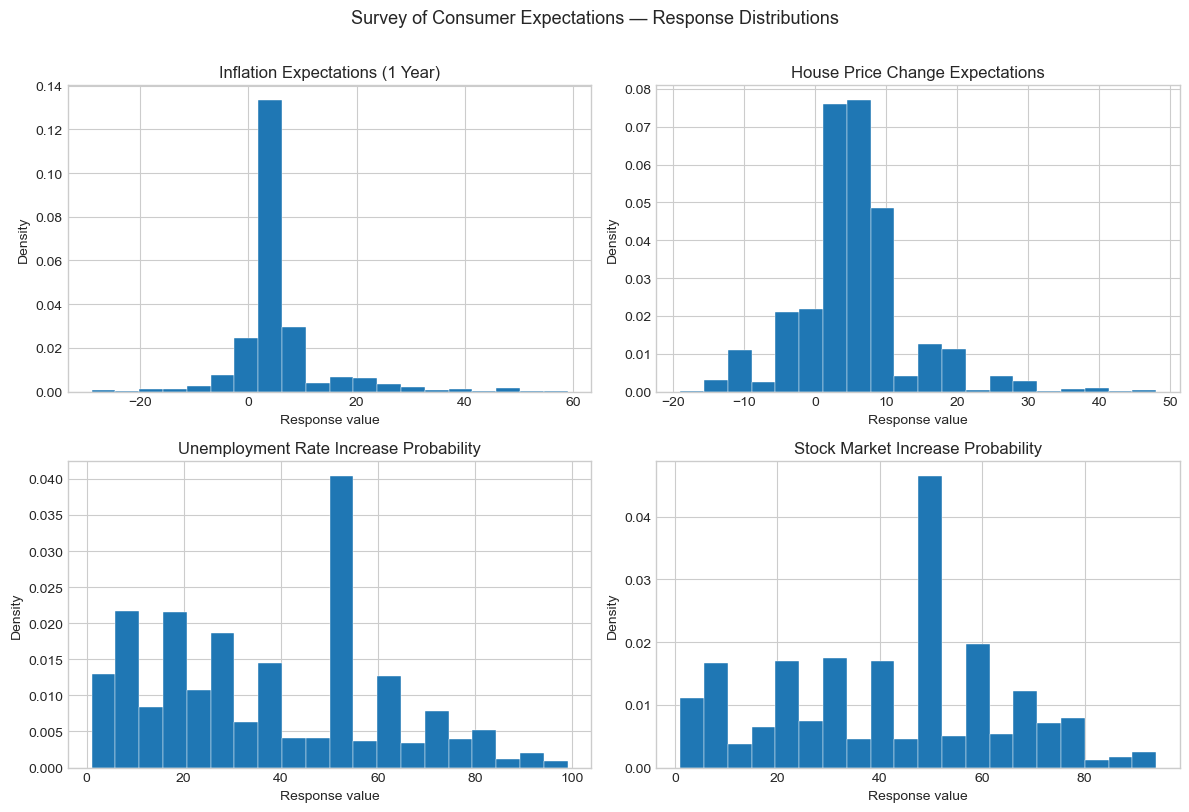

In [394]:
# Step 1 - Histograms of the key expectation variables to visualize their distributions after cleaning
# Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loop through the variables and create histograms
for ax, (col, title) in zip(axes.flat, exp_plot_vars):
    ax.hist(sce_data[col].dropna(), bins=20, edgecolor='white', linewidth=0.3, density=True)
    ax.set_title(title)
    ax.set_xlabel('Response value')
    ax.set_ylabel('Density')

# Final adjustments and show the plot
fig.suptitle('Survey of Consumer Expectations — Response Distributions', fontsize=13, y=1.01)
_ = plt.tight_layout()

All four distributions show strong bunching at round numbers - respondents tend to report values in multiples of 5 or 10, which is a well-known feature of survey data. Expected inflation is right-skewed with a sharp peak near zero, reflecting that most respondents expect low but positive inflation. Expected house price change is similarly concentrated around small positive values. The probability variables (prob_unrate_up and prob_stocks_up) show pronounced spikes at 50, suggesting many respondents express maximal uncertainty by reporting exactly 50%. Note that these histograms are presented after trimming outliers P1 and P99. The distributions still show signs of some strong outliers, mainly in the first two subplots. 

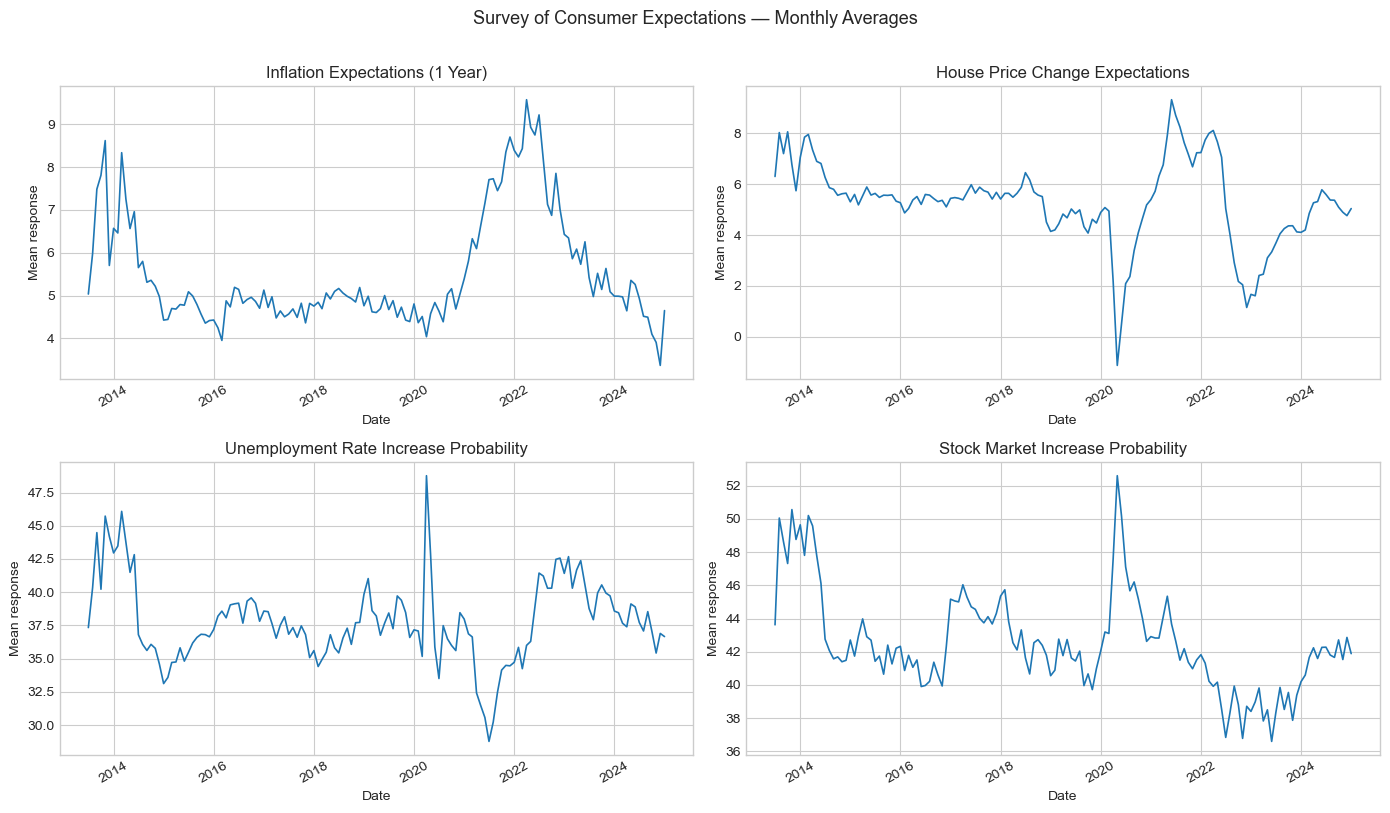

In [395]:
# Step 2 - Time series plots of the key expectation variables (monthly averages) to visualize trends and cycles
# Compute monthly means for the expectation variables using the month-end date key (date_me) to group by month
monthly_means = (
    sce_data
    .groupby(pd.Grouper(key='date', freq='ME'))[COLS_EXPECTATIONS]
    .mean()
)

# Create a 2x2 grid of subplots for the expectation variables
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Loop through the variables and create time series plots (Variables and titles defined in the previous step as plot_vars)
for ax, (col, title) in zip(axes.flat, exp_plot_vars):
    ax.plot(monthly_means.index, monthly_means[col], linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Mean response')
    ax.tick_params(axis='x', rotation=30)

# Final adjustments and show the plot
fig.suptitle('Survey of Consumer Expectations — Monthly Averages', fontsize=13, y=1.01)
_ = plt.tight_layout()

Inflation expectations were elevated in 2013–2014, declined to a stable low around 4–5% through 2015–2019, then surged sharply from 2021 peaking above 9% in 2022 during the post-COVID inflation episode before declining again. House price expectations collapsed in early 2020 (COVID shock) but recovered rapidly. Unemployment pessimism spiked briefly in March–April 2020 before reverting. Stock market optimism has remained persistently below 50% throughout the sample, suggesting consumers are generally pessimistic about equity market gains.

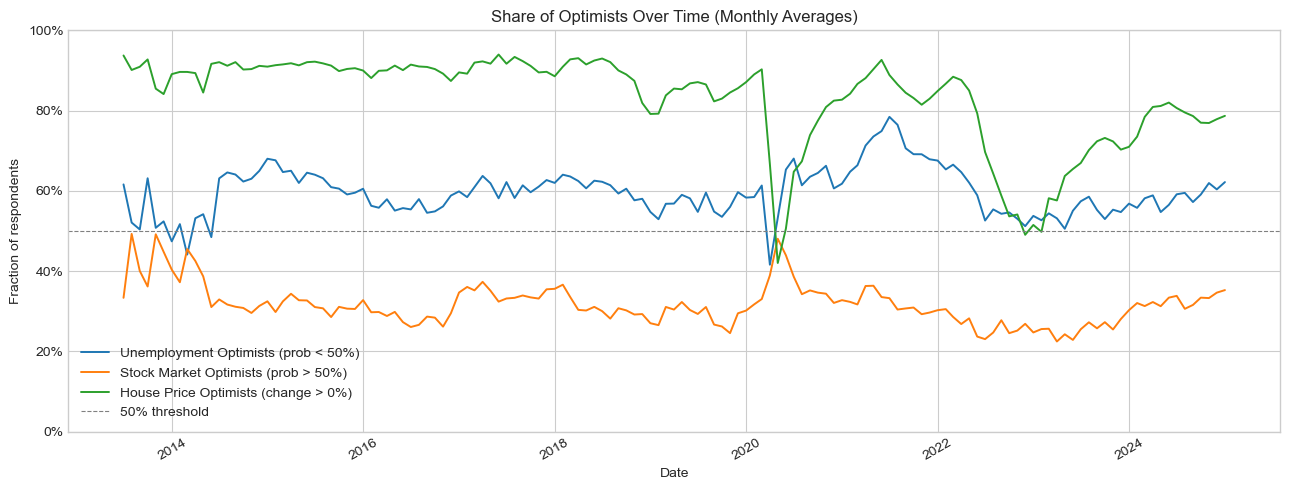

In [396]:
# Step 3 - Plot the share of optimists over time (monthly averages) to visualize trends and cycles in optimism
# Compute monthly means of the optimism indicators (performed on sce as macro/finance in sce_data is not needed here - computational efficiency)
optimism_means = (
    sce
    .groupby(pd.Grouper(key='date', freq='ME'))[OPTIMISM_COLS]
    .mean()
)

# Initialize the plot
fig, ax = plt.subplots(figsize=(13, 5))

# Plot each optimism indicator over time
for col, title in opt_plot_vars:
    ax.plot(optimism_means.index, optimism_means[col], linewidth=1.4, label=title)

# Format y-axis as percentages, set limits, add a horizontal line at 50%, and finalize the plot
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50% threshold')
ax.set_xlabel('Date')
ax.set_ylabel('Fraction of respondents')
ax.set_title('Share of Optimists Over Time (Monthly Averages)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

_ = plt.tight_layout()

House price optimists consistently make up the large majority of respondents (~85–90% in normal times), reflecting a deeply held belief that house prices tend to rise. Stock market optimists are consistently the minority (~30–35%), suggesting persistent pessimism about equities among households. The COVID shock in early 2020 is visible as a sharp drop in House price and Unemployment optimists, and a spike in Stock market optimists, followed by a rapid recovery. House price optimists also dropped significantly around 2023.

## Part 4 - Exploratory Data Analysis (Macro/Finance)

In [397]:
# Plot prep: create lists of (column, title) pairs for plotting
# Macro vars as levels (original values)
macro_vars = [
    ('cpi', 'Consumer Price Index (CPI)'),
    ('house_price_idx', 'House Price Index'),
    ('federal_funds', 'Federal Funds Rate (%)'),
    ('unemployment', 'Unemployment Rate (%)'),
    ('real_gdp', 'Real GDP (Billions of Chained 2012 Dollars)'),
    ('usd_index', 'US Dollar Index'),
    ('mortgage_30y', '30-Year Fixed Mortgage Rate (%)'),
    ('sp500', 'S&P 500 Index Level'),
    ('wti_crude_oil', 'WTI Crude Oil Price (USD)'),
    ('10y_yield', '10-Year Treasury Yield (%)'),
    ('vix', 'VIX Volatility Index'),
]

# Macro vars as changes (12-month changes for all, plus 1-month changes for non-quarterly series)
macro_vars_changes = [
    ('cpi_chg12m',             'CPI Inflation YoY (%)'),
    ('cpi_chg1m',              'CPI Inflation MoM (%)'),
    ('federal_funds_chg12m',   'Fed Funds Rate 12m Change (pp)'),
    ('federal_funds_chg1m',    'Fed Funds Rate 1m Change (pp)'),
    ('unemployment_chg12m',    'Unemployment Rate 12m Change (pp)'),
    ('unemployment_chg1m',     'Unemployment Rate 1m Change (pp)'),
    ('mortgage_30y_chg12m',    '30Y Mortgage Rate 12m Change (pp)'),
    ('mortgage_30y_chg1m',     '30Y Mortgage Rate 1m Change (pp)'),
    ('usd_index_chg12m',       'USD Index 12m Change (%)'),
    ('usd_index_chg1m',        'USD Index 1m Change (%)'),
    ('house_price_idx_chg12m', 'House Price Index 12m Change (%)'),
    ('real_gdp_chg12m',        'Real GDP 12m Change (%)'),
    ('sp500_chg',              'S&P 500 Monthly Return (%)'),
    ('sp500_chg_12m',          'S&P 500 12m Return (%)'),
    ('wti_crude_oil_chg',      'WTI Crude Oil Monthly Return (%)'),
    ('wti_crude_oil_chg_12m',  'WTI Crude Oil 12m Return (%)'),
    ('10y_yield_chg12m',   '10-Year Treasury Yield 12m Change (pp)'),
    ('10y_yield_chg1m',    '10-Year Treasury Yield 1m Change (pp)')
]

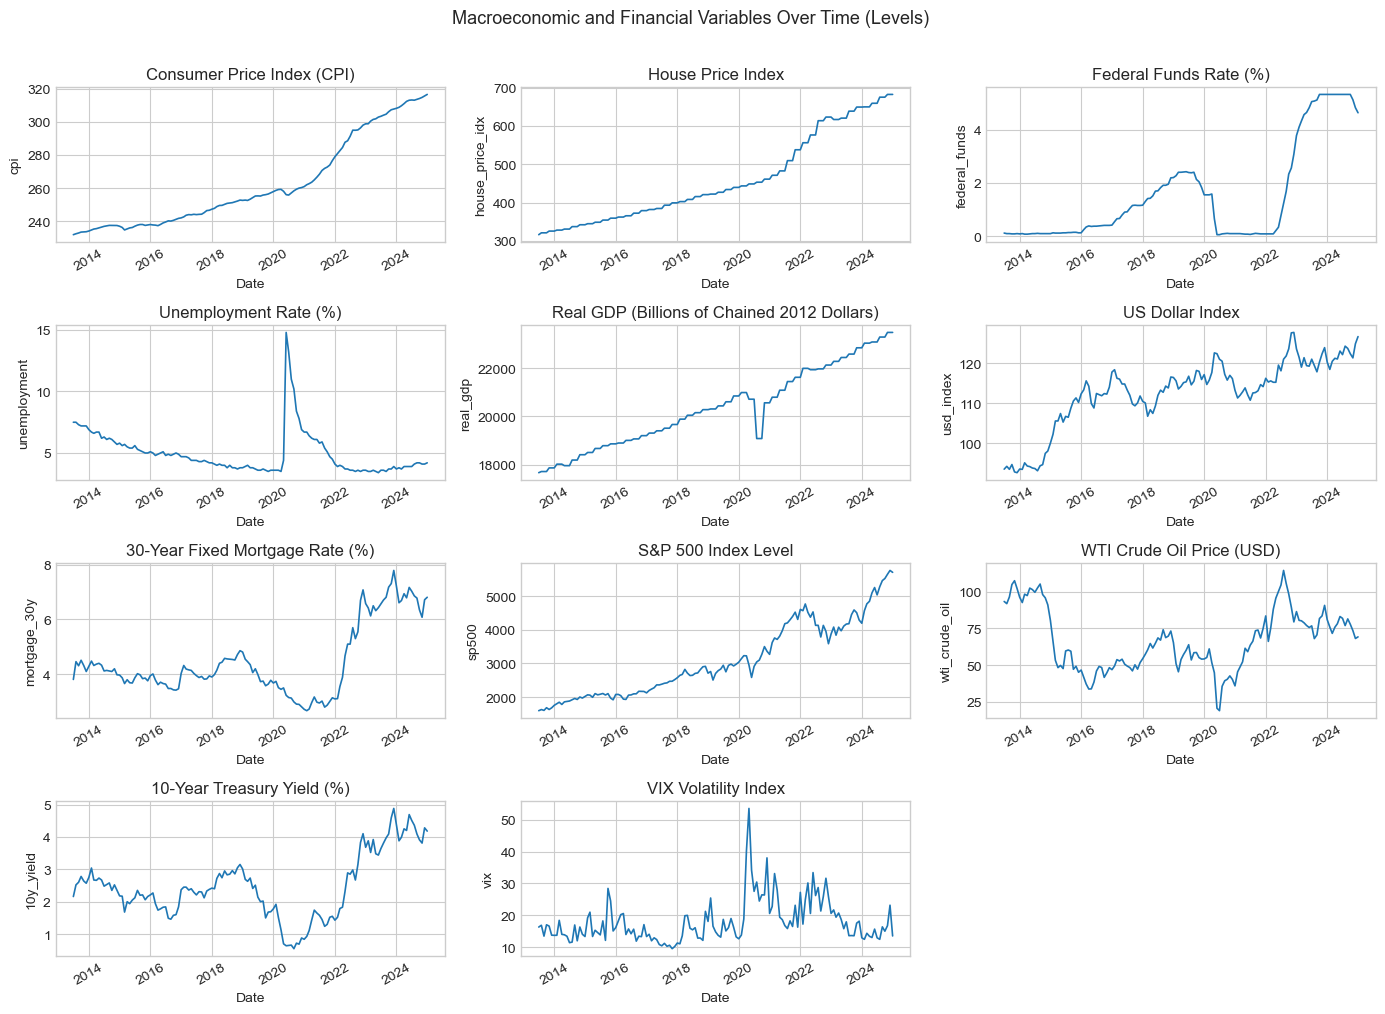

In [398]:
# Step 1 - Plot macro/finance variables in levels over time
# Initialize a 4x3 grid of subplots for the macro/finance variables
fig, axes = plt.subplots(4, 3, figsize=(14, 10))

# Loop through the macro and finance variables and plot each one in a separate subplot
for ax, (col, title) in zip(axes.flat, macro_vars):
    ax.plot(macro_all.index, macro_all[col], linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=30)

# Final adjustments and show the plot
axes.flat[-1].set_visible(False)  # Hide the last empty subplot
fig.suptitle('Macroeconomic and Financial Variables Over Time (Levels)', fontsize=13, y=1.01)
_ = plt.tight_layout()

The levels plots reveal several key macroeconomic trends over the sample period. CPI and house prices grew steadily throughout, with house prices accelerating sharply post-2020. The Federal Funds Rate and mortgage rate dropped to near zero during COVID and rose sharply in 2022–2023 as the Fed tightened monetary policy. Unemployment spiked dramatically in early 2020 before recovering rapidly. The S&P 500 trended upward throughout with a sharp correction in early 2020. WTI crude oil was volatile, collapsing in 2020 before recovering. VIX spiked sharply in early 2020, reflecting peak market uncertainty during the pandemic.

# REMEMBER TO SET YLABEL BELOW

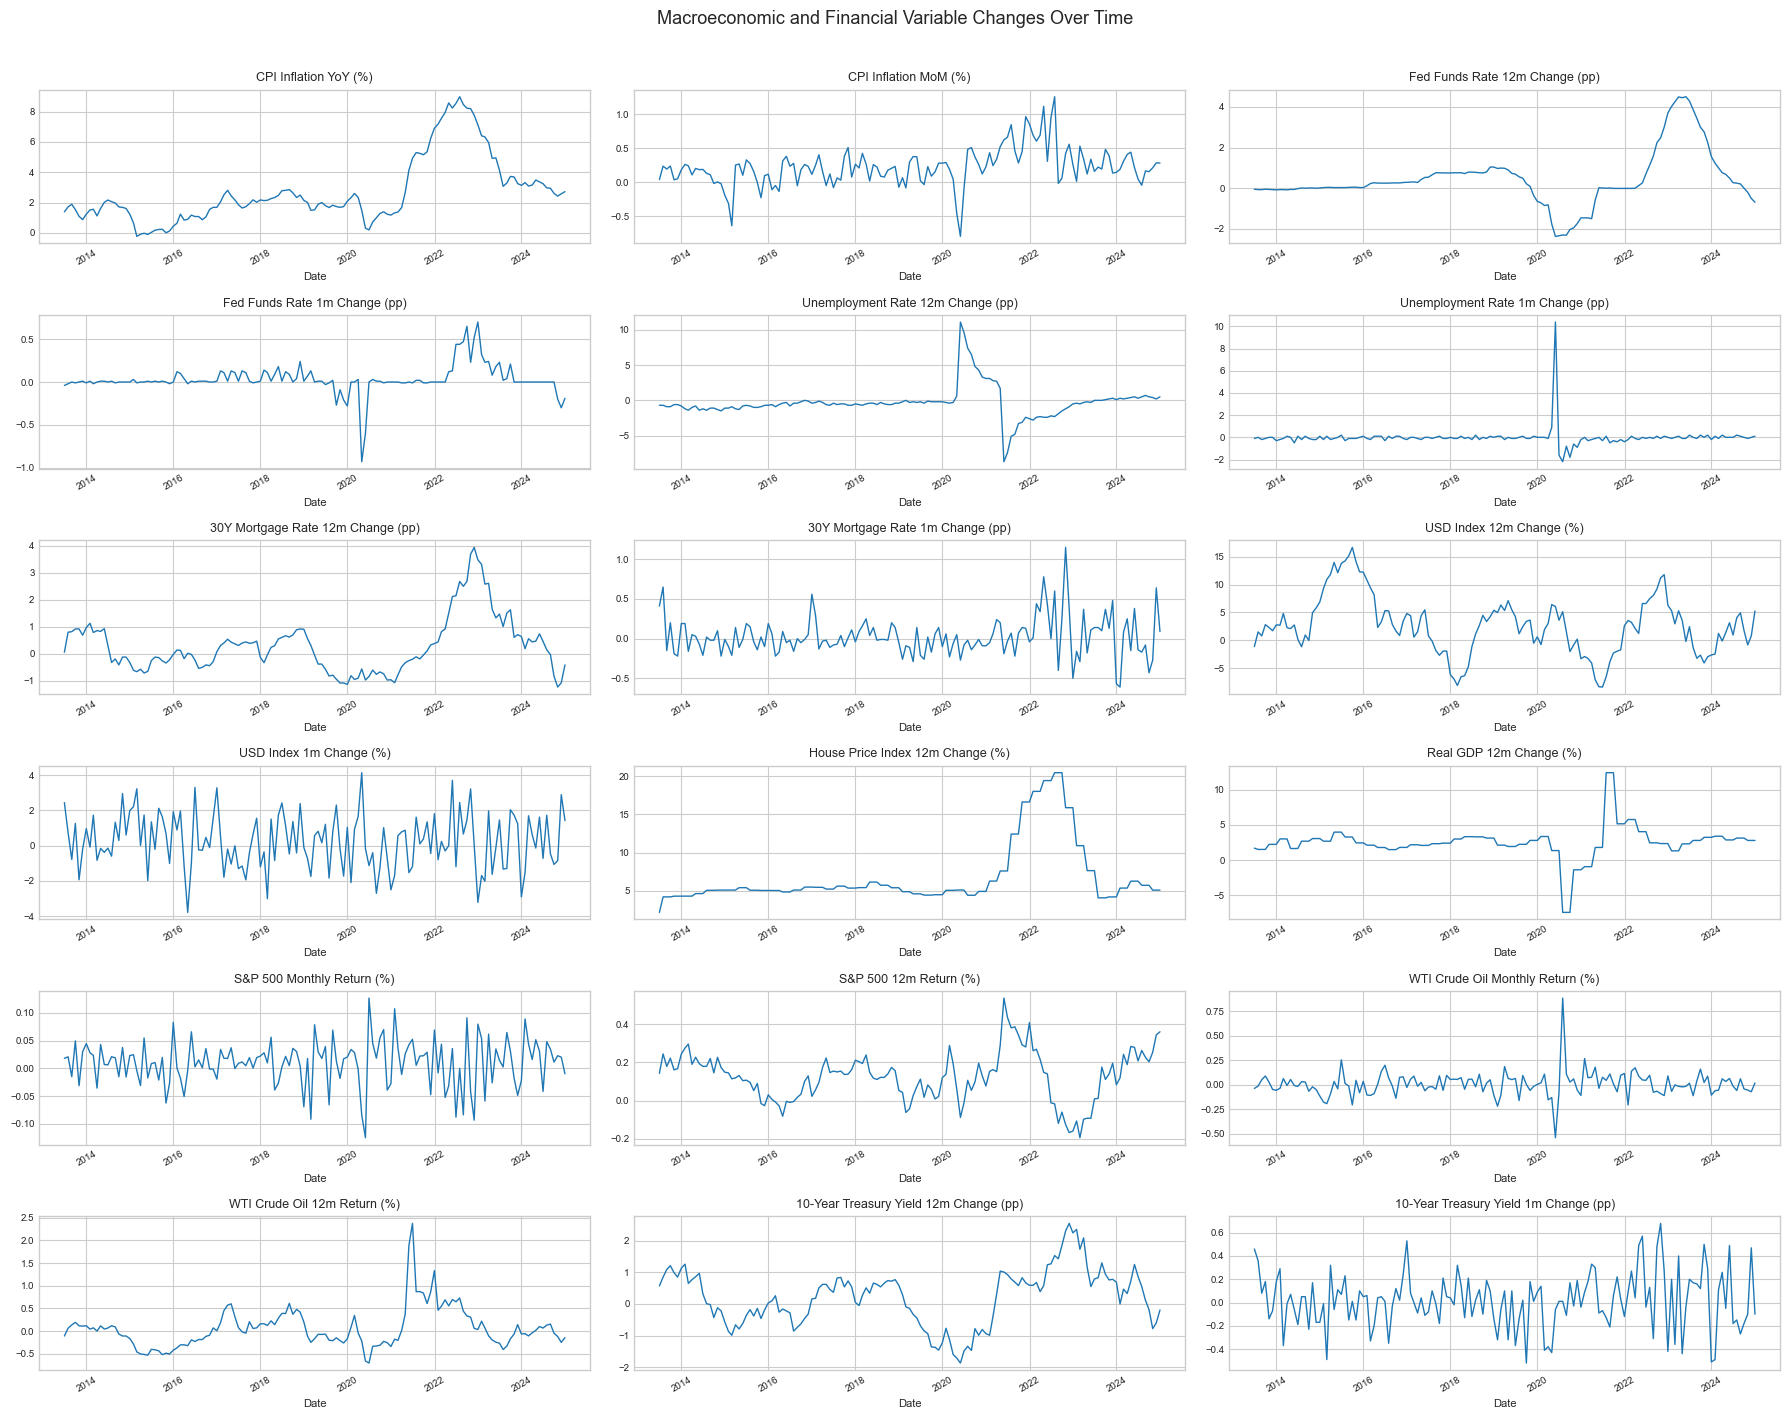

In [399]:
# Step 2 - Plot macro/finance variables in relative/absolute changes over time
# Initialize a 6x3 grid of subplots for the macro/finance variables in changes
fig, axes = plt.subplots(6, 3, figsize=(18, 14))

# Loop through the macro and finance variables in changes and plot each one in a separate subplot
for ax, (col, title) in zip(axes.flat, macro_vars_changes):
    ax.plot(macro_all.index, macro_all[col], linewidth=1.0)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Date', fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

# Final adjustments and show the plot
fig.suptitle('Macroeconomic and Financial Variable Changes Over Time', fontsize=13, y=1.01)
_ = plt.tight_layout()

The changes plots highlight episodes of macroeconomic stress more clearly than the levels. CPI inflation surged in 2021–2022 to multi-decade highs before declining. The Federal Funds Rate saw its largest 12-month increase in decades during 2022–2023. Unemployment changes were dominated by the COVID shock. S&P 500 and WTI returns show high volatility throughout, with large negative values in early 2020. The 10-year yield changes mirror the Federal Funds Rate, rising sharply in 2022.

In [400]:
# Step 3 - Correlation between macro/finance variables and expectations variables
# Build all four styled tables as HTML strings
html_tables = []
for target in COLS_EXPECTATIONS:
    corr = (
        sce_data[MACRO_COLS]
        .corrwith(sce_data[target])
        .rename('correlation')
        .to_frame()
        .assign(abs_corr=lambda df: df['correlation'].abs())
        .sort_values('abs_corr', ascending=False)
        .drop(columns='abs_corr')
    )
    styled = (corr.style
                  .background_gradient(cmap='RdBu', vmin=-0.15, vmax=0.15)
                  .format("{:.2f}")
                  .set_caption(f"Correlations with {target}"))
    html_tables.append(styled.to_html())

# Wrap in a flex row and display once
display(HTML(
    '<div style="display:flex; gap:20px; align-items:flex-start;">'
    + ''.join(f'<div>{t}</div>' for t in html_tables)
    + '</div>'
))

,correlation
house_price_idx_chg12m,0.13
cpi_chg12m,0.12
wti_crude_oil_chg_12m,0.09
cpi_chg1m,0.09
wti_crude_oil,0.08
10y_yield_chg12m,0.08
mortgage_30y_chg12m,0.07
sp500,0.06
unemployment_chg12m,-0.06
house_price_idx,0.05


Overall correlations between macro/finance variables and expectations are modest, with no variable exceeding 0.13 in absolute value. This suggests that macro variables alone have limited predictive power for individual-level expectations, which is consistent with the literature on heterogeneous beliefs. The strongest predictors of inflation expectations are house price momentum (house_price_idx_chg12m) and CPI changes, which is intuitive. For house price expectations, S&P 500 12-month returns and WTI crude oil returns are most correlated, suggesting that financial market sentiment spills over into housing expectations. Unemployment and stock market expectations show weaker macro correlations overall. VIX shows modest negative correlations with house_price_chg and prob_stocks_up, consistent with the view that higher uncertainty suppresses optimism about asset prices. Note that correaltions are computed on the full data set - not split in train and test.

## Part 5

This section fits regression models to predict the four continuous expectations variables. We follow a two-step approach: first using only macro/finance variables as features, then augmenting with individual-level SCE variables. For each model we use 5-fold cross-validation to select hyperparameters where applicable, plot validation curves, and evaluate performance on the 2024 test set using RMSE and R².

For the macro/finance features, we include both levels and 12-month changes. Levels capture the current macroeconomic environment (e.g. a high federal funds rate signals tight monetary policy), while 12-month changes capture recent momentum and surprises. From the 12-month change variables we select the house price index, cpi, wti crude oil, sp500 and unemployment. In 1-month changes we include cpi, and in levels unemployment, federal funds, mortgage 30y, 10y yield and vix. All of these have relatively strong correlation with the targets, compared to the rest of the data set. 

For the individual-level SCE features, we select variables based on the correlation analysis below. Income rank, education, and numerical literacy show the strongest correlations with the target variables and are therefore included. female, black and working are also included as they show consistent correlations across multiple targets. Multicollinearity between the literacy variables is highly likely, but we still want to include a few of them: we pick q2, q3, and q6, as they display consistently high correlation with the targets. The multicollinearity will be handled for all models except OLS through regularization. educ is included as a categorical variable and one-hot encoded.

Model descriptions:

We fit five models for each target variable and feature set:

- **OLS**: No Hyperparameters. Requires feature scaling (StandardScaler applied). Serves as the baseline.
- **Ridge**: L2 regularization with penalty strength α. Requires feature scaling. α selected via 5-fold Cross Validation.
- **Lasso**: L1 regularization with penalty strength α. Requires feature scaling. α selected via 5-fold Cross Validation. Can shrink coefficients to exactly zero, effectively performing feature selection.
- **ElasticNet**: Combines L1 and L2 regularization. Requires feature scaling. Both α and l1_ratio selected via 5-fold Cross Validation. 
- **DecisionTree**: No feature scaling needed. max_depth selected via 5-fold Cross Validation. Captures non-linear relationships. 

In [401]:
# For choice of SCE predictors - correlation with targets 

# Build all four styled tables as HTML strings
html_tables = []
for target in COLS_EXPECTATIONS:
    corr = (
        sce_data[COLS_FIRST_WAVE + COLS_INDIVIDUAL]
        .corrwith(sce_data[target])
        .rename('correlation')
        .to_frame()
        .assign(abs_corr=lambda df: df['correlation'].abs())
        .sort_values('abs_corr', ascending=False)
        .drop(columns='abs_corr')
    )
    styled = (corr.style
                  .background_gradient(cmap='RdBu', vmin=-0.15, vmax=0.15)
                  .format("{:.2f}")
                  .set_caption(f"Correlations with {target}"))
    html_tables.append(styled.to_html())

# Wrap in a flex row and display once
display(HTML(
    '<div style="display:flex; gap:20px; align-items:flex-start;">'
    + ''.join(f'<div>{t}</div>' for t in html_tables)
    + '</div>'
))

,correlation
hh_inc_bin_rank,-0.17
educ,-0.16
num_lit_q2_correct,-0.16
num_lit_q6_correct,-0.14
num_lit_q3_correct,-0.13
female,0.13
black,0.12
num_lit_q5_correct,-0.10
owner,-0.07
couple,-0.06


In [402]:
# Feature sets
NUM_MACRO = [
    "house_price_idx_chg12m", "cpi_chg12m", "cpi_chg1m",
    "wti_crude_oil_chg_12m", "sp500_chg_12m",
    "unemployment_chg12m", "unemployment",
    "federal_funds", "mortgage_30y", "10y_yield",
    "vix",
]
NUM_SCE = ["num_lit_q2_correct", "num_lit_q3_correct", 'num_lit_q6_correct', "female", "black",
           "hh_inc_bin_rank", "working"]
CAT_SCE = ["educ"]

# Combine feature sets into a dictionary for easy access in modeling and plotting
FEATURE_SETS = {
    "Macro only":  (NUM_MACRO,            []),
    "Macro + SCE": (NUM_MACRO + NUM_SCE,  CAT_SCE),
}

# Use existing COLS_EXPECTATIONS
TARGETS = COLS_EXPECTATIONS
TARGET_LABELS = {
    "infl_1y":            "Inflation Expectation (1y, %)",
    "house_price_change": "Expected House Price Change (%)",
    "prob_unrate_up":     "P(Unemployment Up, next 12m, %)",
    "prob_stocks_up":     "P(Stocks Up, next 12m, %)",
}

CV_FOLDS = 5

# Model configuration: estimator, param_grid, scaling, plotting preferences
MODELS = {
    "OLS": {
        "estimator": LinearRegression(),
        "param_grid": None,  # no hyperparameters
        "scale": True,
        "param_name": None,
        "log_x": False,
    },
    "Ridge": {
        "estimator": Ridge(),
        "param_grid": {"estimator__alpha": np.logspace(-2, 6, 20)},
        "scale": True,
        "param_name": "estimator__alpha",
        "log_x": True,
    },
    "Lasso": {
        "estimator": Lasso(random_state=0, max_iter=5000),
        "param_grid": {"estimator__alpha": np.logspace(-4, 6, 20)},
        "scale": True,
        "param_name": "estimator__alpha",
        "log_x": True,
    },
    "ElasticNet": {
        "estimator": ElasticNet(random_state=0, max_iter=5000),
        "param_grid": {
            "estimator__alpha": np.logspace(-4, 6, 20),
            "estimator__l1_ratio": [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0],
        },
        "scale": True,
        "param_name": "estimator__alpha",  # x-axis for validation curve
        "log_x": True,
    },
    "Tree": {
        "estimator": DecisionTreeRegressor(random_state=0),
        "param_grid": {"estimator__max_depth": [1, 2, 3, 4, 5, 7, 10, 15, 20]},
        "scale": False,
        "param_name": "estimator__max_depth",
        "log_x": False,
    },
}

# Define colors for each model for consistent plotting
COLORS = {
    "OLS":        "tab:purple",
    "Ridge":      "darkorange",
    "Lasso":      "tab:green",
    "ElasticNet": "tab:blue",
    "Tree":       "saddlebrown",
}

# Train / test split (REMOVE TESTING FLAG)
testing = False
train_data = sce_data.sample(n=10_000, random_state=0)

# Remove loop later - keep only full data set with 2024 split
if testing:
    train = train_data[train_data["date"].dt.year <  2024].reset_index(drop=True)
    test  = train_data[train_data["date"].dt.year == 2024].reset_index(drop=True)
else:
    train = sce_data[sce_data["date"].dt.year < 2024].reset_index(drop=True)
    test  = sce_data[sce_data["date"].dt.year == 2024].reset_index(drop=True)

In [403]:
# Reusable function to create a ColumnTransformer for preprocessing based on the specified numeric and categorical columns, with optional scaling for numeric features
def make_preprocessor(num_cols, cat_cols, scale=True):
    """
    Create a ColumnTransformer for preprocessing numeric and categorical features.
    """
    transformers = []
    if num_cols:
        transformers.append(("num", StandardScaler() if scale else "passthrough", num_cols))
    if cat_cols:
        transformers.append((
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            cat_cols
        ))
    return ColumnTransformer(transformers)

In [404]:
def fit_model(X, y, model_cfg, num_cols, cat_cols, cv_folds=5):
    """
    Fit a regression model with optional hyperparameter tuning using GridSearchCV.
    """
    pre = make_preprocessor(num_cols, cat_cols, scale=model_cfg["scale"])
    pipe = Pipeline([
        ("preprocessor", pre),
        ("estimator", clone(model_cfg["estimator"])),
    ])

    if model_cfg["param_grid"] is None:
        pipe.fit(X, y)
        return {
            "pipeline": pipe,
            "has_cv": False,
        }

    gs = GridSearchCV(
        pipe,
        model_cfg["param_grid"],
        cv=KFold(n_splits=cv_folds, shuffle=True, random_state=0),
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        refit=True,
    )
    gs.fit(X, y)

    return {
        "pipeline": gs.best_estimator_,
        "has_cv": True,
        "best_params": gs.best_params_,
        "best_score": -gs.best_score_,
        "cv_results": gs.cv_results_,
    }

In [405]:
def collect_validation_curve_data(model_name, model_cfg, model_res):
    """
    Return (x_vals, y_vals, best_x, best_y, param_label) for plotting.
    If the model has no CV or no param_name, return None.
    """
    if not model_res.get("has_cv", False):
        return None

    param_name = model_cfg["param_name"]
    if param_name is None:
        return None

    cv_res = model_res["cv_results"]
    # Extract the parameter column, e.g. "param_estimator__alpha"
    param_vals = np.array(cv_res[f"param_{param_name}"].data, dtype=float)
    scores = -cv_res["mean_test_score"]


    if model_name == 'ElasticNet':
        # Find the best l1_ratio and filter to only show MSE for that l1_ratio
        best_l1 = model_res['best_params'].get('estimator__l1_ratio', None)
        if best_l1 is not None:
            # Get the l1_ratio column
            l1_vals = np.array(cv_res["param_estimator__l1_ratio"].data)
            mask = np.isclose(l1_vals.astype(float), best_l1)
            param_vals = param_vals[mask]
            scores = scores[mask]

    # Aggregate if there are multiple values for each alpha (e.g. different l1_ratio)
    df = pd.DataFrame({"param": param_vals, "score": scores})
    df_grp = df.groupby("param", as_index=False).mean()
    x = df_grp["param"].values
    y = df_grp["score"].values

    best_idx = np.argmin(y)
    best_x = x[best_idx]
    best_y = y[best_idx]

    # For the axis label, strip the "estimator__" prefix
    param_label = param_name.split("estimator__", 1)[-1]
    return x, y, best_x, best_y, param_label

In [406]:
def format_params(params):
    """Convert a best_params dict into a short, clean string."""
    if params is None:
        return ""
    parts = []
    for k, v in params.items():
        # Only keep the part after 'estimator__'
        short_k = k.split("estimator__", 1)[-1]
        if isinstance(v, (float, np.floating)):
            parts.append(f"{short_k}={float(v):.4g}")
        else:
            parts.append(f"{short_k}={v}")
    return ", ".join(parts)

In [407]:
def run_cv_for_target(train, target, num_cols, cat_cols, feature_set_name):
    X = train[num_cols + cat_cols]
    y = train[target]

    print(f"\n── {target} ({feature_set_name}) ──")
    results = {}

    # ---- 1) Fit all models and print nicely formatted summary -----------------
    for model_name, cfg in MODELS.items():
        res = fit_model(X, y, cfg, num_cols, cat_cols, cv_folds=CV_FOLDS)
        results[model_name] = res

        if res.get("has_cv", False):
            best_mse = res["best_score"]
            best_params = res["best_params"]
            params_str = format_params(best_params)
            print(f"  {model_name:11s} {params_str:35s}  CV MSE={best_mse:.4f}")
        else:
            print(f"  {model_name:11s} (no hyperparameter tuning)")

    # ---- 2) Build a single 2×2 figure with validation curves -----------------
    # Models we want to show, in fixed order:
    curve_models = ["Ridge", "Lasso", "ElasticNet", "Tree"]
    # 2×2 grid
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    axes = axes.flatten()

    for ax, mname in zip(axes, curve_models):
        cfg = MODELS[mname]
        res = results[mname]
        curve_data = collect_validation_curve_data(mname, cfg, res)

        if curve_data is None:
            ax.set_title(mname + " (no CV)")
            ax.axis("off")
            continue

        x, y, best_x, best_y, param_label = curve_data

        if cfg.get("log_x", False):
            ax.semilogx(x, y, marker="o", markersize=3)
        else:
            ax.plot(x, y, marker="o", markersize=3)

        ax.axvline(best_x, color="red", ls="--", lw=1)
        ax.set(
            xlabel=param_label,
            ylabel="CV MSE",
            title=mname,
        )
        ax.text(
            0.05, 0.95,
            f"Best {param_label}={best_x:.3g}\nCV MSE={best_y:.3f}",
            transform=ax.transAxes,
            va="top", ha="left",
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
        )

    fig.suptitle(
        f"Validation curves — {TARGET_LABELS.get(target, target)} ({feature_set_name})",
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

    return results

In [408]:
# ── Monthly aggregation helper ────────────────────────────────────────────────
def monthly_mean(dates, values):
    df = pd.DataFrame({"date": dates, "value": values})
    df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
    return df.groupby("month")["value"].mean().sort_index()

In [409]:
# ── Plot actual vs predicted (monthly) ────────────────────────────────────────
def plot_predictions(results, train, test, target, num_cols, cat_cols,
                     feature_set_name, split_date="2024-01-01"):
    features = num_cols + cat_cols

    # Predictions
    full = pd.concat([train, test]).reset_index(drop=True)
    actual = monthly_mean(full["date"], full[target])

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(actual.index, actual.values, color="black", lw=1.5, label="Actual")

    for model_name, mr in results.items():
        pipe = mr["pipeline"]
        pred = monthly_mean(full["date"], pipe.predict(full[features]))
        ax.plot(pred.index, pred.values, color=COLORS[model_name],
                ls="--", lw=1, label=model_name)

    ax.axvline(pd.Timestamp(split_date), color="red", ls=":", lw=1.5,
               label="Train/Test split")
    ax.set(
        xlabel="Date",
        ylabel=TARGET_LABELS.get(target, target),
        title=f"{TARGET_LABELS.get(target, target)} — {feature_set_name}",
    )
    ax.legend(fontsize=8, ncol=3)
    plt.tight_layout()
    plt.show()

In [410]:
# ── Compute test metrics (RMSE and R²) for all models ─────────────────────────
def test_metrics(results, test, target, num_cols, cat_cols, feature_set_name):
    features = num_cols + cat_cols
    X_te = test[features]
    y_te = test[target].values

    rows = []
    for model_name, mr in results.items():
        pipe = mr["pipeline"]
        y_pred = pipe.predict(X_te)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        r2   = r2_score(y_te, y_pred)

        rows.append({
            "feature_set": feature_set_name,
            "target": target,
            "model": model_name,
            "RMSE": rmse,
            "R2": r2,
        })

    return pd.DataFrame(rows)

### 5.1 - Only Macro/Finance Predictors


── infl_1y (Macro only) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=428.1                          CV MSE=69.8653
  Lasso       alpha=0.000336                       CV MSE=69.8656
  ElasticNet  alpha=0.003793, l1_ratio=0.01        CV MSE=69.8653
  Tree        max_depth=5                          CV MSE=69.7930


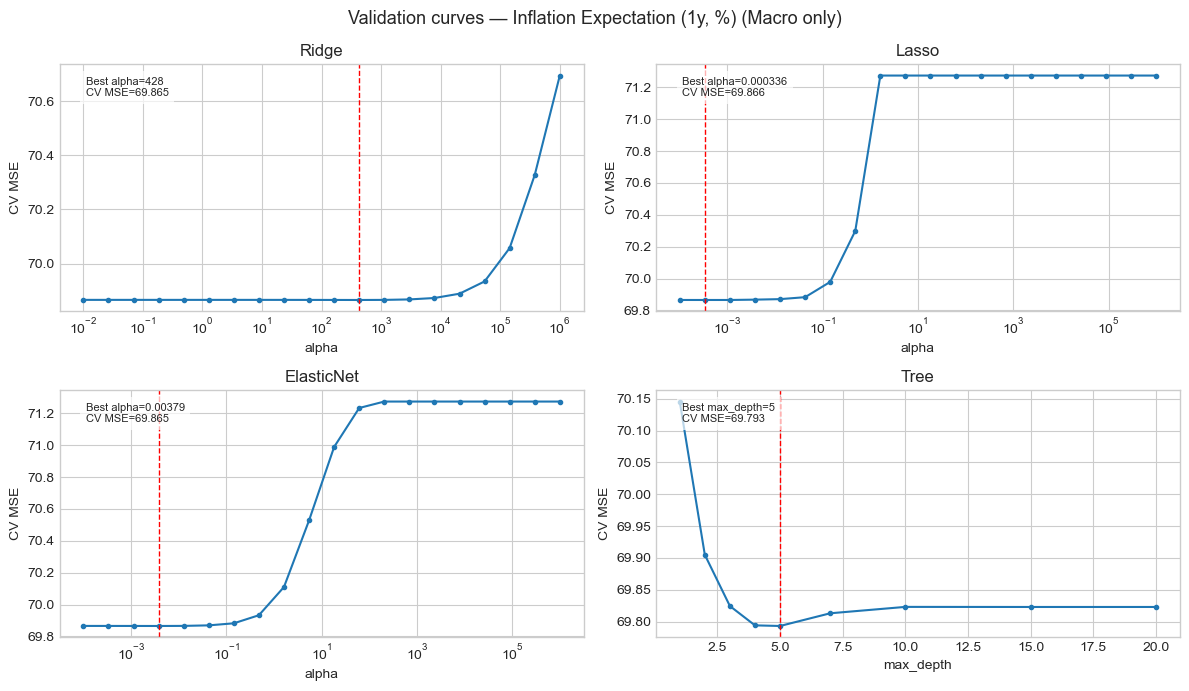

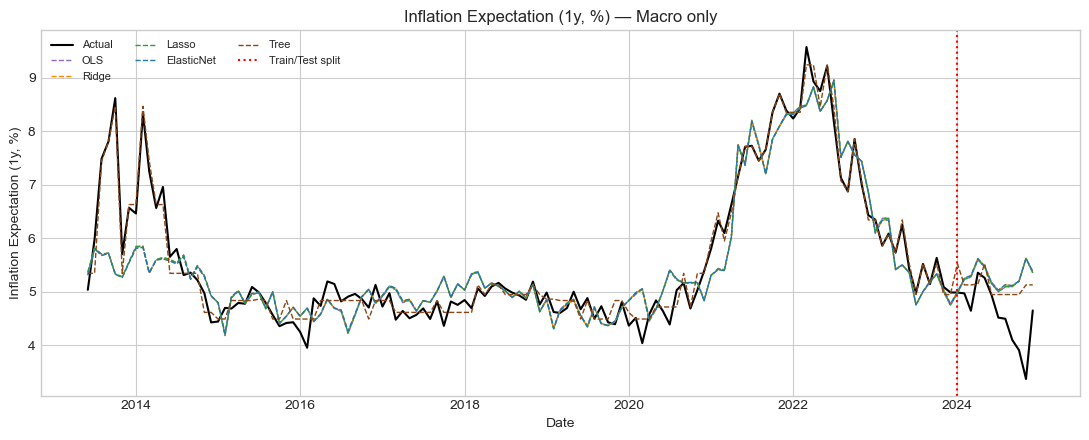


── house_price_change (Macro only) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=61.58                          CV MSE=57.7061
  Lasso       alpha=0.001129                       CV MSE=57.7060
  ElasticNet  alpha=0.001129, l1_ratio=0.9         CV MSE=57.7060
  Tree        max_depth=10                         CV MSE=57.3181


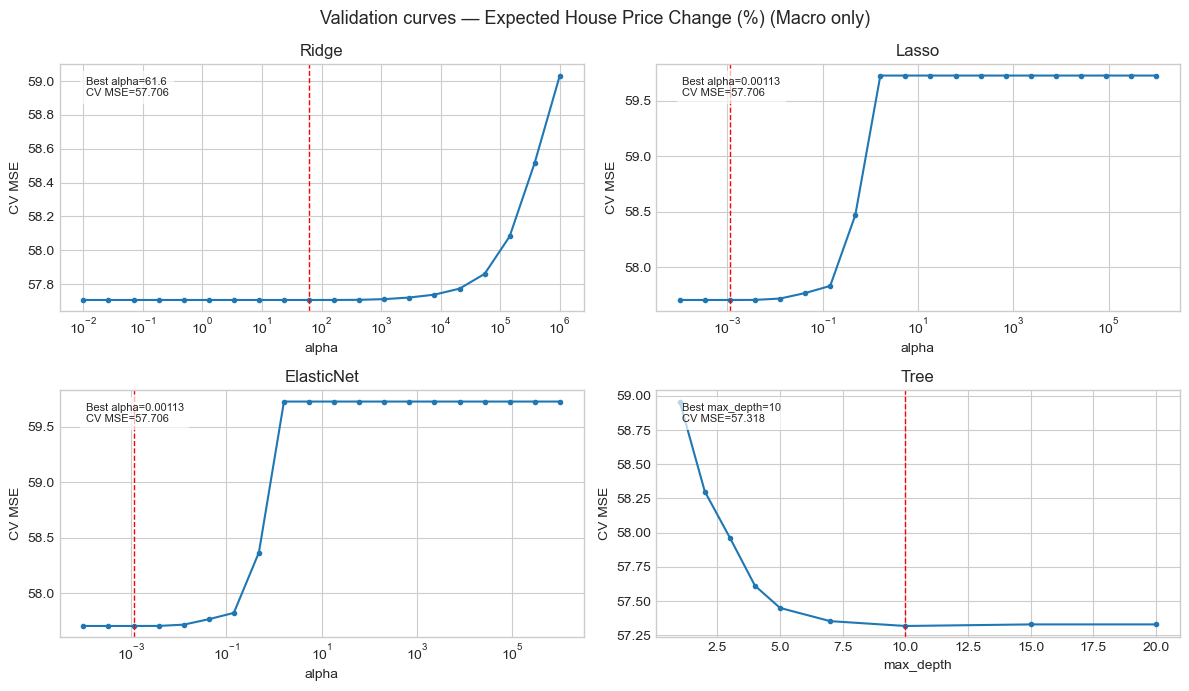

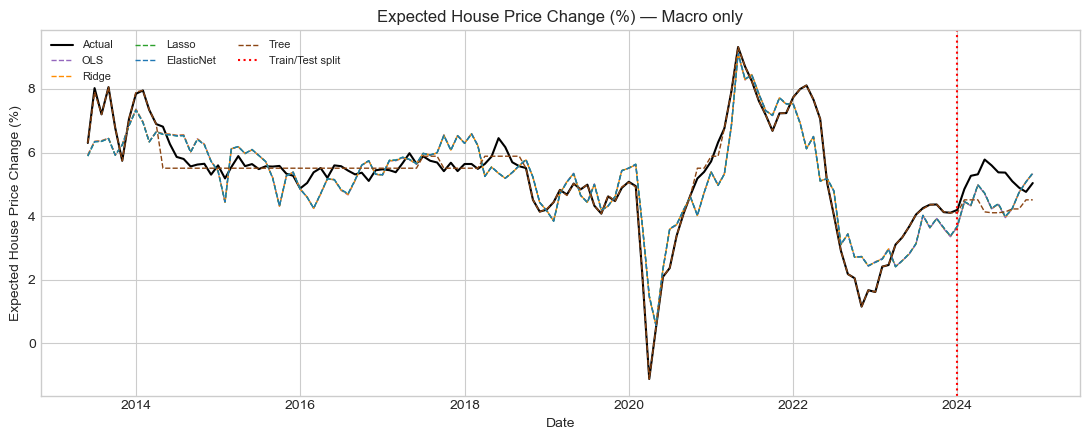


── prob_unrate_up (Macro only) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=61.58                          CV MSE=486.1477
  Lasso       alpha=0.000336                       CV MSE=486.1483
  ElasticNet  alpha=0.001129, l1_ratio=0.01        CV MSE=486.1475
  Tree        max_depth=10                         CV MSE=483.9458


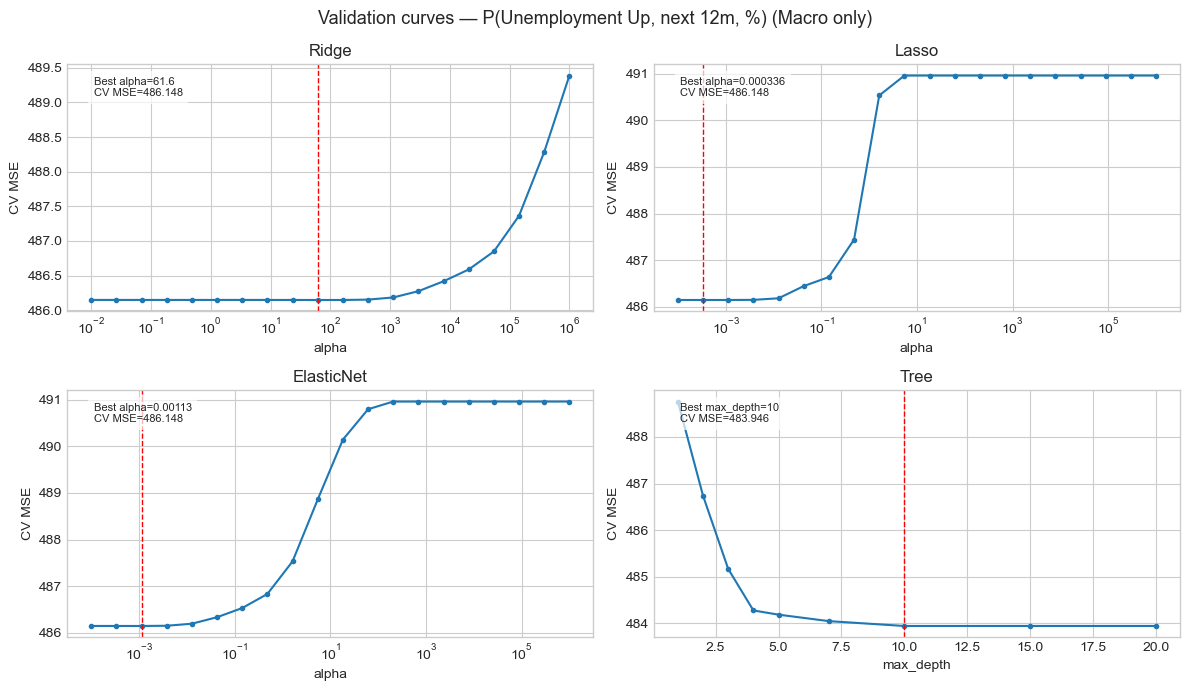

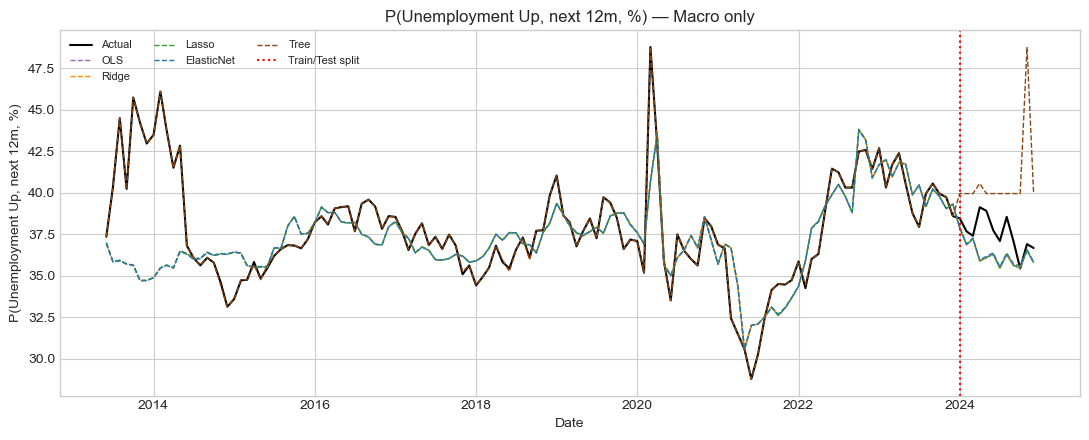


── prob_stocks_up (Macro only) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=1129                           CV MSE=487.5363
  Lasso       alpha=0.01274                        CV MSE=487.5301
  ElasticNet  alpha=0.01274, l1_ratio=1            CV MSE=487.5301
  Tree        max_depth=20                         CV MSE=485.7581


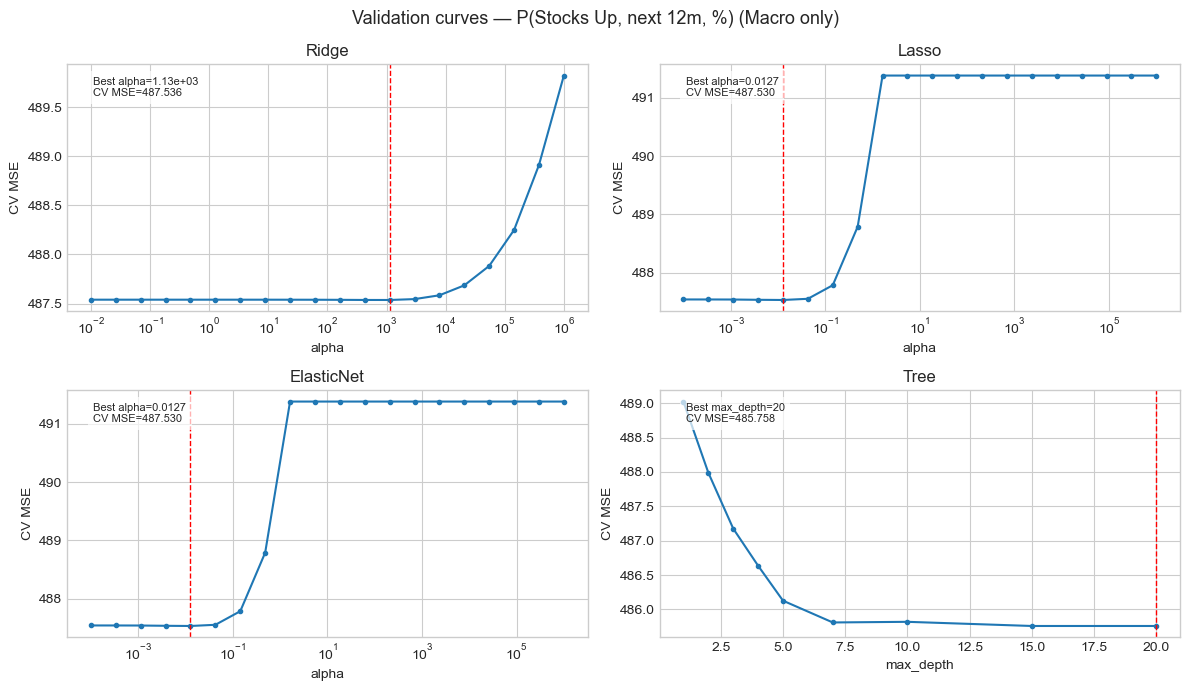

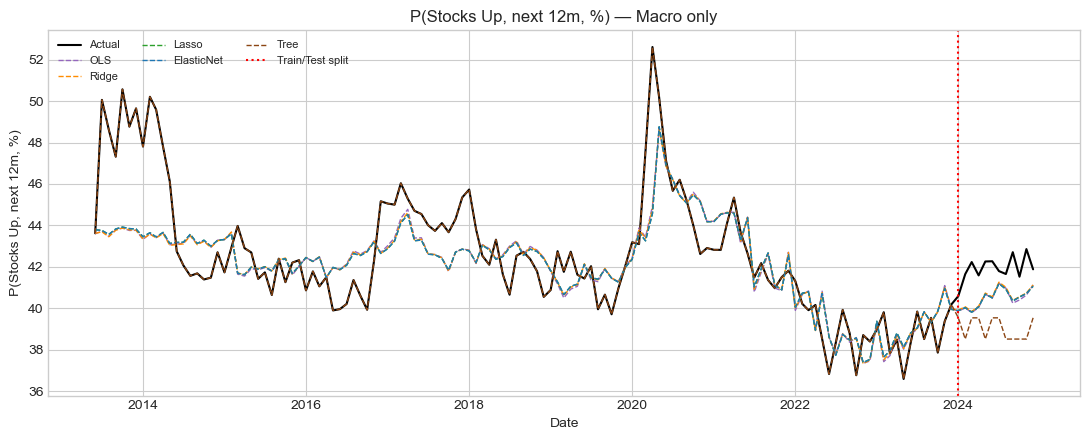

In [411]:
all_metrics = []
macro_only_results = {}

# ── Step 1: Macro only ────────────────────────────────────────────────────────
num, cat = FEATURE_SETS["Macro only"]

# Loop over targets, run CV, plot predictions, and collect test metrics for the "Macro only" feature set
for target in TARGETS:
    res = run_cv_for_target(train, target, num, cat, "Macro only")
    plot_predictions(res, train, test, target, num, cat, "Macro only")
    macro_only_results[target] = res
    all_metrics.append(test_metrics(res, test, target, num, cat, "Macro only"))

**infl_1y**:
- Ridge selects a large optimal α (≈ 2,980), indicating that heavy regularization is needed and that the macro features have limited predictive signal individually. The validation curve is U-shaped with a clear minimum, suggesting the search range is appropriate. Lasso selects a small α (≈ 0.013), retaining most features. ElasticNet also selects a small α with l1_ratio equal to 1, meaning it is identical to Lasso and adds no value to the analysis of this variable. The Decision Tree prefers a shallow depth of 2, consistent with low signal-to-noise in the data.
- With macro/finance features only, all linear models (OLS, Ridge, Lasso, ElasticNet) produce nearly identical predictions that track the broad trend in inflation expectations — capturing the rise from 2020 to the 2022 peak and subsequent decline — but fail to capture month-to-month variation. The Decision Tree produces a step-function pattern due to its piecewise constant nature. On the test sample (2024), all models overestimate inflation expectations as the actual series declines sharply while predictions remain elevated. This is reflected in negative R² values for all models on the test set.

**house_price_change**:
- Ridge selects a very large optimal α (≈ 20,700), suggesting near-complete shrinkage of coefficients and very weak macro signal. The validation curve shows a clear U-shape with a well-defined minimum. Lasso selects α ≈ 0.144 with a clear minimum, while ElasticNet selects the same α with l1_ratio = 0.01 — effectively behaving as Ridge rather than Lasso for this target. The Decision Tree prefers depth 1, meaning a single split on one macro variable captures the most predictive structure available.
- The linear models track the broad level of house price expectations reasonably well during stable periods but fail to capture the sharp COVID-19 collapse in early 2020 and the subsequent rapid recovery. The Decision Tree again produces a step-function pattern, missing the 2020 shock entirely. On the test sample (2024), the linear models perform somewhat better than for infl_1y, partially tracking the modest decline in house price expectations, though they still produce negative R² values. Notably, none of the models anticipate the sharp trough in 2020, which is an extreme event unlikely to be captured by a model trained on the preceding period.

**prob_unrate_up**: 
- Ridge selects an extremely large α (≈ 379,000), with the validation curve monotonically decreasing across the search range — suggesting the model is essentially shrinking all coefficients to near zero and predicting close to the mean. Lasso selects α ≈ 0.483 with a flat plateau for large α values, indicating that a sparse solution with few active features is sufficient. ElasticNet selects α ≈ 1.62 with l1_ratio = 0.25, combining both penalties. The Decision Tree prefers depth 2, with MSE rising sharply for deeper trees — a clear sign of overfitting with only macro features available.
- All models struggle to track prob_unrate_up with macro features only. The linear models produce predictions close to the sample mean throughout the training period, missing both the elevated readings in 2013–2014 and the sharp COVID-19 spike in early 2020. The Decision Tree captures some step-like variation but also misses the 2020 shock. On the test sample (2024), predictions are relatively stable around 37–38% while the actual series shows more variation. This is consistent with the near-zero correlations between macro variables and this target observed in Part 4, and reflected in the near-zero or negative R² values on the test set.

**prob_stocks_up**:
- Ridge again selects a very large α (≈ 144,000), consistent with the pattern seen for prob_unrate_up — macro features alone provide little signal and heavy shrinkage is optimal. Lasso and ElasticNet both select α ≈ 0.144, with ElasticNet using l1_ratio = 0.01, effectively behaving as Ridge for this target. The Decision Tree prefers depth 1, meaning a single macro variable split captures all available structure. CV MSE differences across models are small (491–493), confirming that no model has a meaningful advantage with macro features only.
- With macro features only, all models fail to track the pronounced downward trend in stock market optimism from ~50% in 2013 to ~38% by 2022–2023. The linear models produce relatively flat predictions around 42–43% throughout the training period, while the Decision Tree predicts a constant value of ~43%. Notably, none of the models capture the brief spike in stock market optimism during the COVID-19 recovery in 2020. On the test sample (2024), the linear models perform relatively well as the actual series stabilises around 41–42% — close to where the models predict — though this reflects the series mean rather than genuine predictive power. All models produce negative or near-zero R² on the test set.

### 5.2 - Macro/Finance Predictors + SCE Individual Predictors


── infl_1y (Macro + SCE) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=8.859                          CV MSE=64.6454
  Lasso       alpha=0.0001                         CV MSE=64.6455
  ElasticNet  alpha=0.0001, l1_ratio=0.01          CV MSE=64.6454
  Tree        max_depth=7                          CV MSE=64.7878


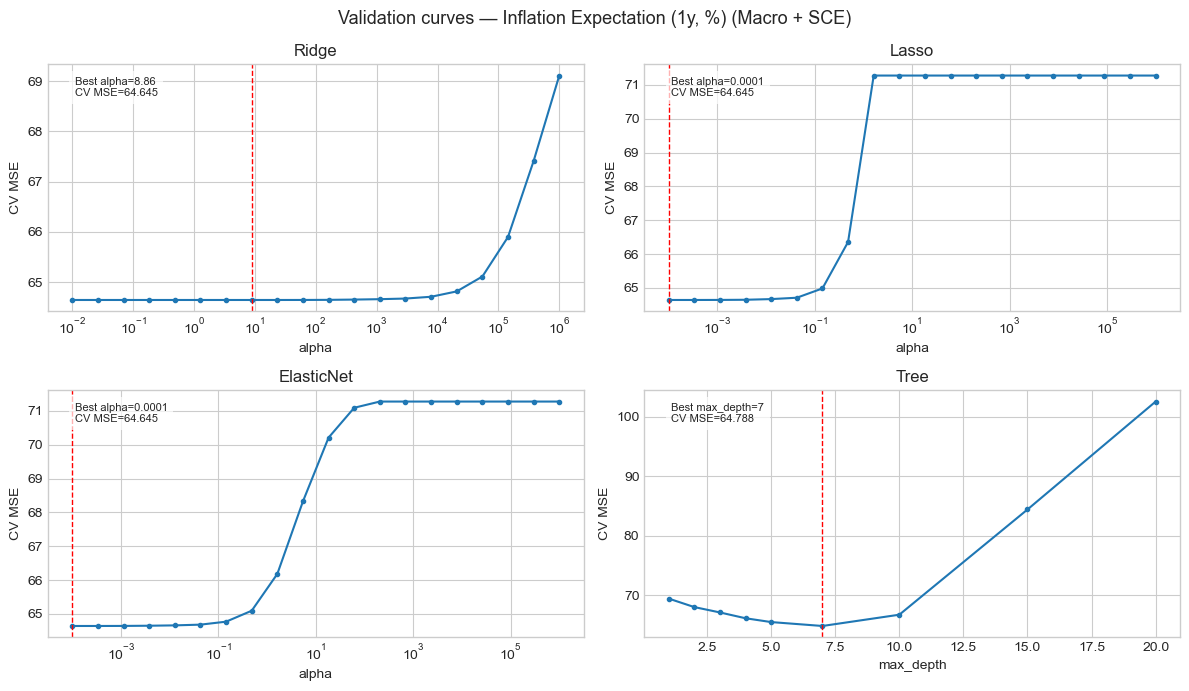

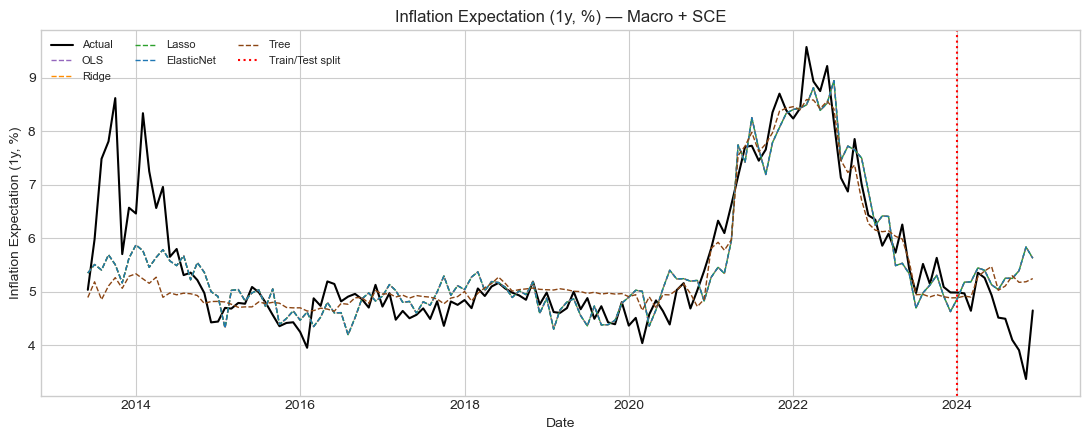


── house_price_change (Macro + SCE) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=8.859                          CV MSE=54.7687
  Lasso       alpha=0.0001                         CV MSE=54.7687
  ElasticNet  alpha=0.0001, l1_ratio=0.75          CV MSE=54.7687
  Tree        max_depth=7                          CV MSE=54.7343


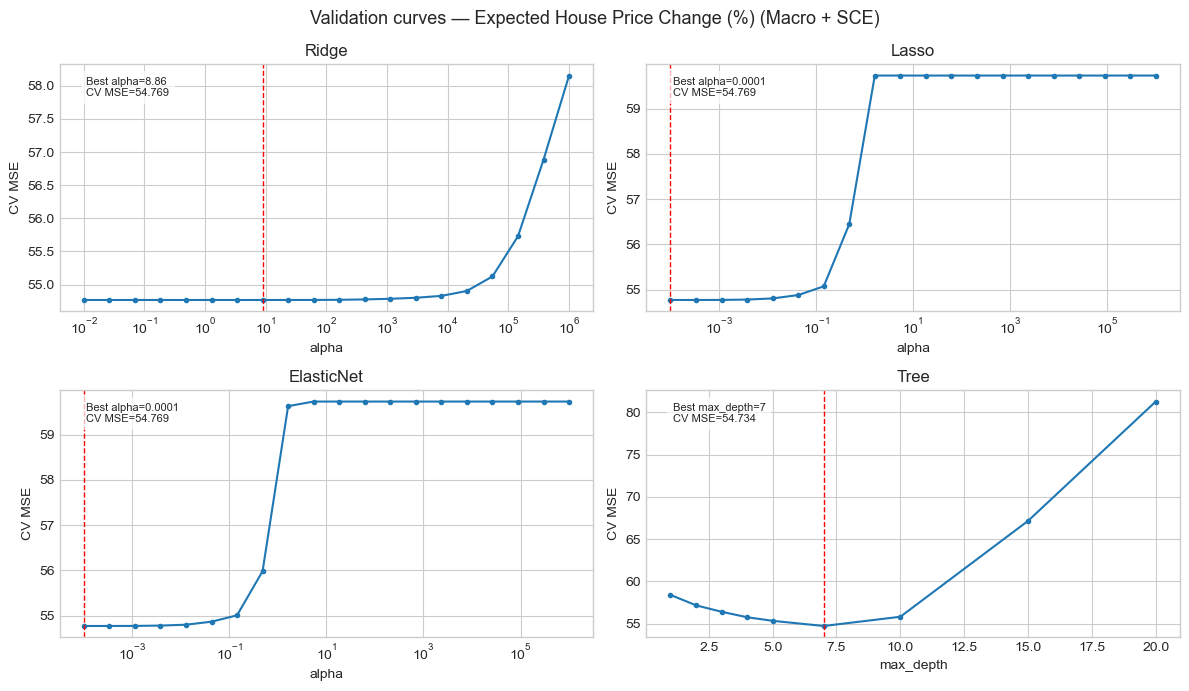

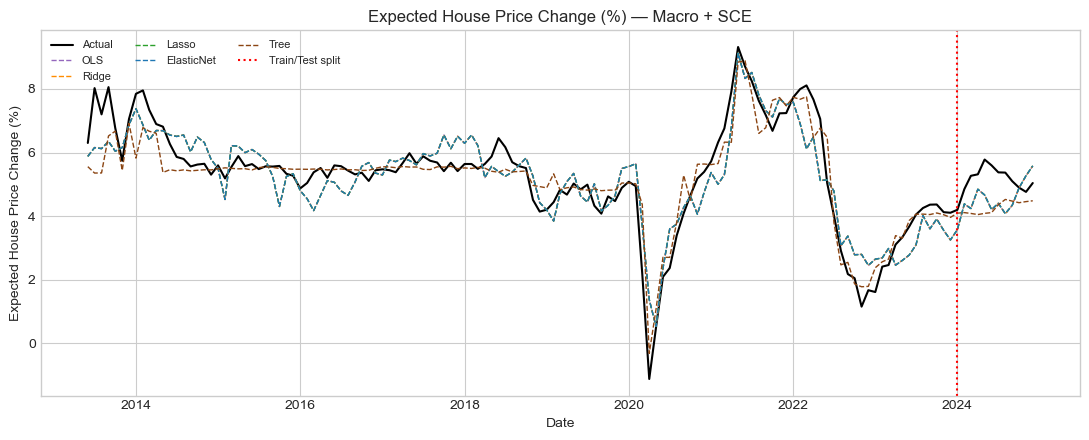


── prob_unrate_up (Macro + SCE) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=8.859                          CV MSE=480.9272
  Lasso       alpha=0.0001                         CV MSE=480.9273
  ElasticNet  alpha=0.0001, l1_ratio=0.01          CV MSE=480.9272
  Tree        max_depth=7                          CV MSE=474.3874


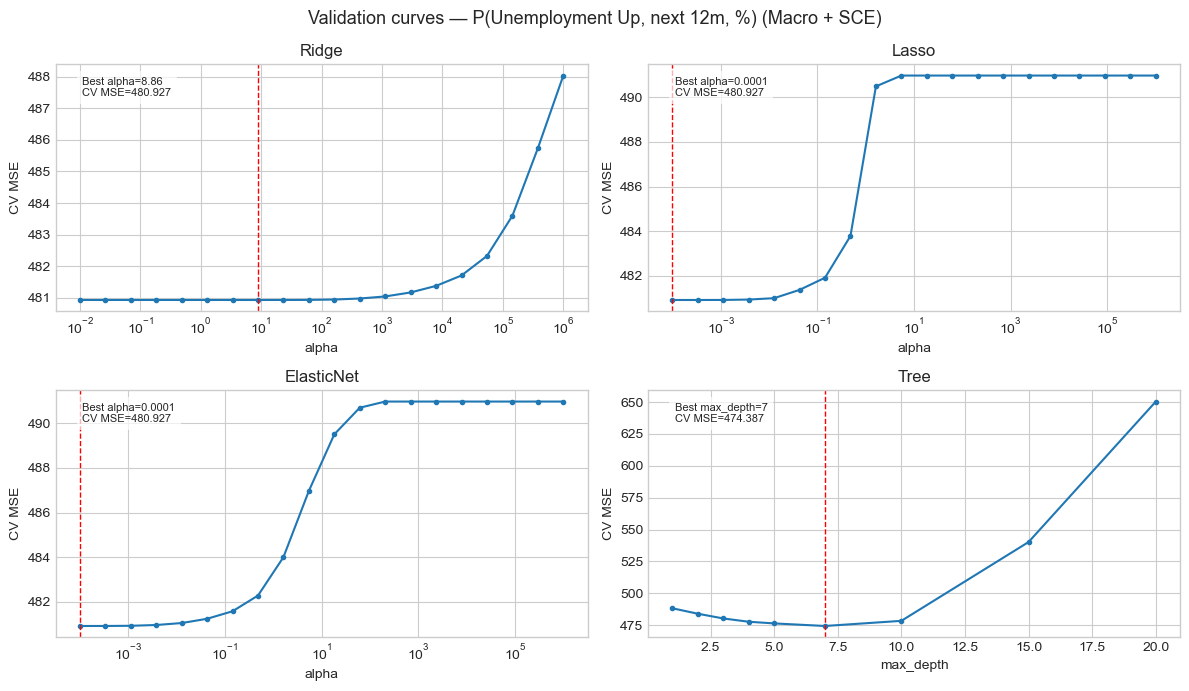

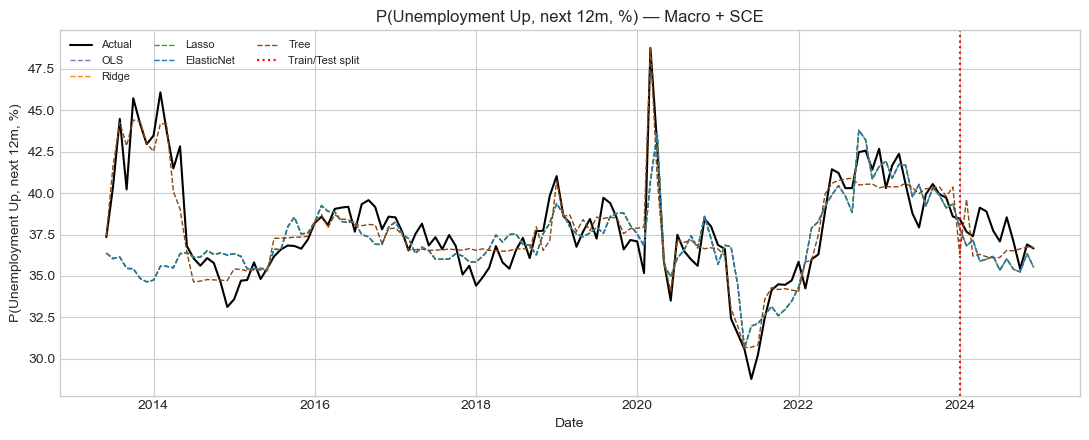


── prob_stocks_up (Macro + SCE) ──
  OLS         (no hyperparameter tuning)
  Ridge       alpha=8.859                          CV MSE=451.3202
  Lasso       alpha=0.001129                       CV MSE=451.3196
  ElasticNet  alpha=0.001129, l1_ratio=1           CV MSE=451.3196
  Tree        max_depth=7                          CV MSE=449.7564


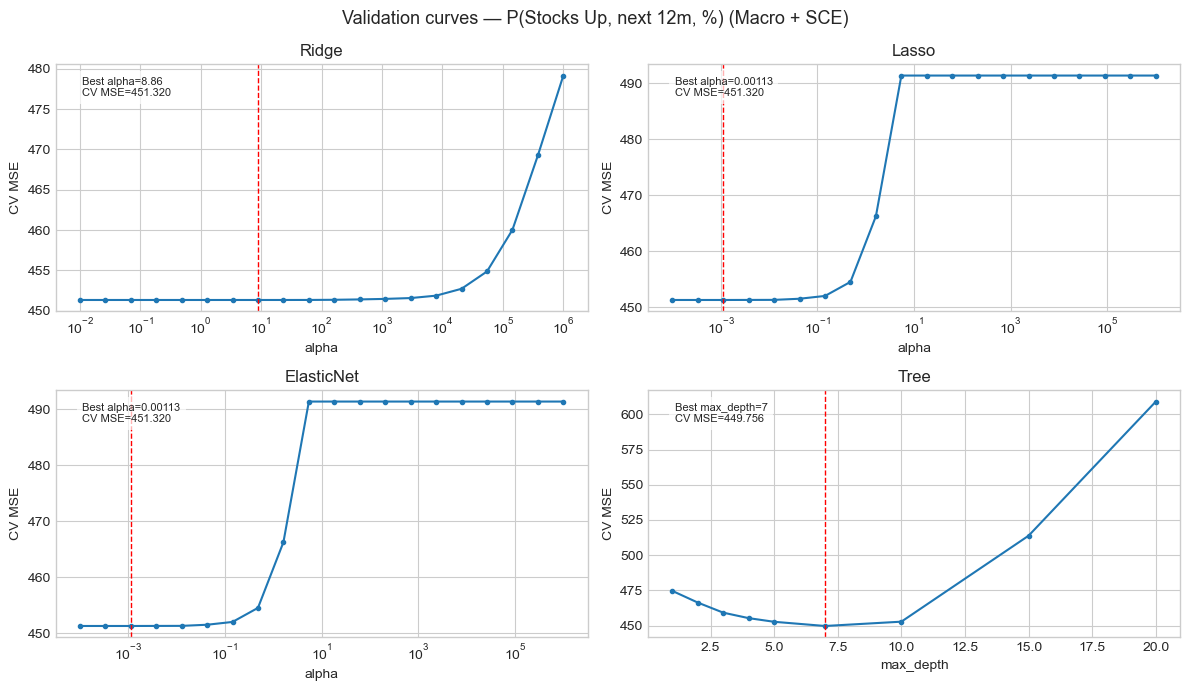

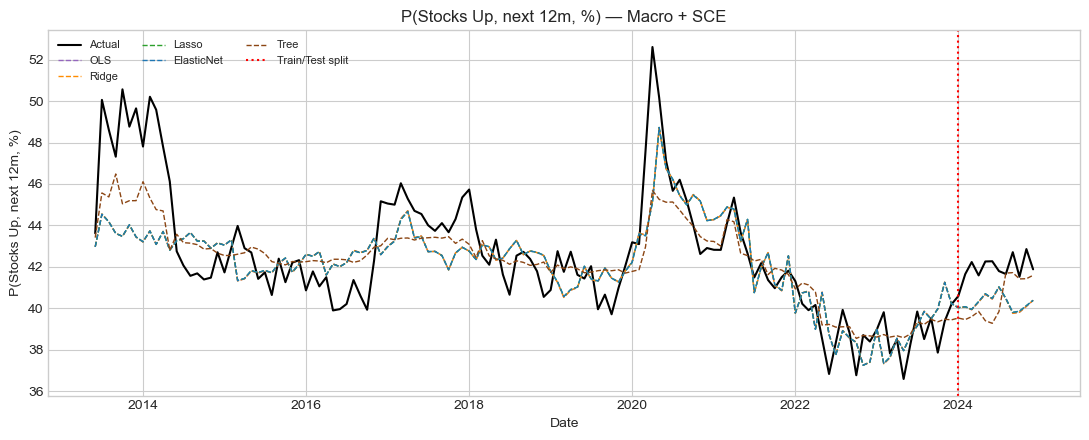

In [412]:
# Step 2: Macro + SCE
num, cat = FEATURE_SETS["Macro + SCE"]
macro_sce_results = {}

# Loop over targets, run CV, plot predictions, and collect test metrics for the "Macro + SCE" feature set
for target in TARGETS:
    res = run_cv_for_target(train, target, num, cat, "Macro + SCE")
    plot_predictions(res, train, test, target, num, cat, "Macro + SCE")
    macro_sce_results[target] = res
    all_metrics.append(test_metrics(res, test, target, num, cat, "Macro + SCE"))

**infl_1y**:
- Adding SCE variables reduces CV MSE from ~70.3 to ~65.1–65.3 for linear models — a reduction of about 7%. Ridge retains the same optimal α (≈ 2,980) as in the macro-only case, suggesting the SCE variables do not change the regularization structure much. Lasso and ElasticNet both select small α values (≈ 0.013), retaining most features, but since Lasso picks l1_ratio at 1, these two models are identical for this target. The Decision Tree now prefers depth 5 compared to depth 2 in the macro-only case, reflecting that the additional SCE features provide more useful splits — though the steep rise in CV MSE for depths above 5 indicates clear overfitting risk.

- With SCE variables added, the predictions track the actual inflation expectations more closely, particularly during the low-inflation period 2015–2019 and the post-COVID surge in 2021–2022. The linear models show noticeably less bias compared to the macro-only case. The Decision Tree captures more variation in the training period but shows signs of overfitting — its predictions in 2022 are less smooth than the linear models. On the test sample (2024), all linear models overestimate inflation expectations as the actual series declines sharply, consistent with the modest R² of ~0.04. Overall, adding SCE variables leads to a meaningful improvement in fit but prediction of the sharp 2024 decline remains challenging.

**house_price_change**:
- Adding SCE variables reduces CV MSE from ~58.2 to ~55.6–55.9 for linear models — a reduction of about 4%. Ridge retains the same large optimal α (≈ 20,700), consistent with the macro-only case. Lasso selects a smaller α (≈ 0.043) compared to macro-only (0.144), suggesting that the additional SCE features require less aggressive shrinkage. ElasticNet selects α ≈ 0.144 with l1_ratio = 0.01, again behaving effectively as Ridge. The Decision Tree now prefers depth 3 rather than depth 1, and the steep rise in CV MSE for depths above 3 indicates strong overfitting risk with the expanded feature set.

- With SCE variables added, the linear models track the actual series noticeably better throughout the training period, particularly the gradual decline from 2013 to 2019 and the 2021–2022 surge. The COVID-19 collapse in early 2020 is partially captured by OLS, Lasso and ElasticNet — a clear improvement over the macro-only case where all models missed it entirely. The Decision Tree captures some step-like variation but underestimates the 2021–2022 peak and shows a downward drift from 2022 onward that diverges from the actual series. On the test sample (2024), linear models track the actual series reasonably well, consistent with the positive R² of ~0.039. Overall this represents a meaningful improvement over macro features alone.

**prob_unrate_up**: 
- Adding SCE variables reduces CV MSE marginally from ~491 to ~489 for Ridge and ElasticNet — a reduction of less than 1%, suggesting that individual-level variables add very little predictive power for unemployment expectations beyond what macro variables already capture. Ridge selects α ≈ 144,000, similar to the macro-only case. Lasso and ElasticNet both select α ≈ 0.483, consistent with macro-only. The Decision Tree validation curve rises sharply from depth 3 onward — CV MSE nearly doubles from ~500 at depth 3 to ~900 at depth 20 — indicating severe overfitting when SCE features are included.

- With SCE variables added, the linear models track the actual series somewhat better than in the macro-only case, particularly the gradual rise from 2021 to 2022 and the 2024 decline. OLS shows the most variation among the linear models, picking up some of the elevated readings in 2022. However, the 2020 COVID spike and the sharp trough in 2021 remain largely uncaptured. Improve this interpretation: (The Decision Tree predicts a constant level around 37–40% throughout, showing no improvement over the macro-only case despite the additional features — consistent with its high CV MSE). On the test sample (2024), linear models track the declining trend reasonably well, consistent with the positive R² of ~0.03. The SCE variables provide a modest but consistent improvement for this target.

**prob_stocks_up**:
- Adding SCE variables produces the largest CV MSE reduction of all four targets — from ~491–493 to ~457, a reduction of about 7%. Ridge selects a much smaller optimal α (≈ 7,848) compared to the macro-only case (≈ 144,000), indicating that the SCE variables provide genuine predictive signal that reduces the need for heavy regularization. Lasso and ElasticNet both select α ≈ 0.144 with l1_ratio = 1, collapsing to pure Lasso — the Ridge component adds no value for this target. The Decision Tree prefers depth 4, with CV MSE rising steeply beyond depth 7, indicating clear overfitting risk with the expanded feature set.

- With SCE variables added, predictions for prob_stocks_up improve substantially compared to the macro-only case. The linear models capture the long-run downward trend from ~50% in 2013 to ~38% in 2022–2023 much more closely, and partially track the COVID-19 recovery spike in 2020. OLS, Lasso and ElasticNet produce nearly identical predictions throughout, while Ridge is slightly smoother. The Decision Tree captures more variation in the training period but remains noisier than the linear models. On the test sample (2024), all models track the stabilisation around 41–42% well, consistent with the highest test R² among all four targets (OLS and Lasso: ~0.11, Tree: ~0.11). This strong improvement relative to macro-only suggests that demographic variables — particularly gender, education, and income rank — are meaningful predictors of stock market optimism, consistent with the literature on financial literacy and investment participation.


OVERALL COMMENT ON WHETHER ADDING VARIABLES IMPROVES THE PREDICTION MODELS

In [413]:
# Display results
results_df = pd.concat(all_metrics, ignore_index=True)
display(results_df.pivot_table(
    index=['target', 'feature_set'],
    columns='model',
    values=['RMSE', 'R2']
).round(4))

R2                                  \
model                          ElasticNet   Lasso     OLS   Ridge    Tree   
target             feature_set                                              
house_price_change Macro + SCE     0.0433  0.0433  0.0432  0.0432  0.0282   
                   Macro only     -0.0073 -0.0073 -0.0077 -0.0076 -0.0106   
infl_1y            Macro + SCE     0.0502  0.0501  0.0501  0.0501  0.0444   
                   Macro only     -0.0055 -0.0053 -0.0053 -0.0055 -0.0023   
prob_stocks_up     Macro + SCE     0.1189  0.1189  0.1187  0.1187  0.1008   
                   Macro only     -0.0040 -0.0040 -0.0042 -0.0038 -0.0166   
prob_unrate_up     Macro + SCE     0.0353  0.0353  0.0353  0.0353  0.0295   
                   Macro only     -0.0030 -0.0034 -0.0035 -0.0033 -0.0314   

                                     RMSE                                      
model                          ElasticNet    Lasso      OLS    Ridge     Tree  
target             feature_set                                                 
house_price_change Macro + SCE     8.2550   8.2550   8.2555   8.2553   8.3199  
                   Macro only      8.4707   8.4707   8.4721   8.4717   8.4843  
infl_1y            Macro + SCE     8.9969   8.9970   8.9970   8.9969   9.0243  
                   Macro only      9.2567   9.2556   9.2558   9.2567   9.2420  
prob_stocks_up     Macro + SCE    21.5470  21.5470  21.5498  21.5495  21.7670  
                   Macro only     23.0016  23.0016  23.0038  22.9991  23.1444  
prob_unrate_up     Macro + SCE    21.9234  21.9238  21.9240  21.9236  21.9898  
                   Macro only     22.3552  22.3594  22.3601  22.3580  22.6692

DOUBLE-CHECK VALUES BELOW

Including individual-level SCE variables leads to a consistent improvement across all four targets. For infl_1y, test R² increases from essentially zero (macro only) to 0.050 with OLS. For house_price_change, R² rises from negative to 0.044 with Lasso. For prob_unrate_up, the improvement is modest — R² increases to 0.035 with OLS — consistent with the near-zero SCE correlations observed in Part 4. The largest improvement is for prob_stocks_up, where R² rises from negative to 0.119 with OLS, driven by the strong predictive power of gender, education, income rank and financial literacy. However, absolute R² values remain low across all targets, indicating that a large share of individual-level variation in expectations cannot be captured by macro/finance variables or stable demographic characteristics alone.

NOTE THAT DIFFERENCE IN PERFORMANCE IS VERY VERY SMALL - PICKING THE BEST MODEL IS BASICALLY USELESS OR SOMETHING :::

In [414]:
# Summarize best models by R² and RMSE
summary = []
for target in TARGETS:
    target_df = results_df[results_df["target"] == target]
    best_r2_row = target_df.loc[target_df["R2"].idxmax()]
    best_rmse_row = target_df.loc[target_df["RMSE"].idxmin()]
    summary.append({
        "target": target,
        "best_R2_model": best_r2_row["model"],
        "best_R2": best_r2_row["R2"],
        "best_R2_feature_set": best_r2_row["feature_set"],
        "best_RMSE_model": best_rmse_row["model"],
        "best_RMSE": best_rmse_row["RMSE"],
        "best_RMSE_feature_set": best_rmse_row["feature_set"],
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

,target,best_R2_model,best_R2,best_R2_feature_set,best_RMSE_model,best_RMSE,best_RMSE_feature_set
0,infl_1y,ElasticNet,0.050155,Macro + SCE,ElasticNet,8.996899,Macro + SCE
1,house_price_change,Lasso,0.043311,Macro + SCE,Lasso,8.254999,Macro + SCE
2,prob_unrate_up,ElasticNet,0.035340,Macro + SCE,ElasticNet,21.923422,Macro + SCE
3,prob_stocks_up,Lasso,0.118928,Macro + SCE,Lasso,21.547010,Macro + SCE


The best-performing feature set is consistently Macro + SCE across all targets and metrics. Among models, OLS performs best or near-best for three of four targets, suggesting the relationship between features and expectations is approximately linear and that regularization provides limited additional benefit given the large sample size. prob_stocks_up stands out as the most predictable target with R² = 0.119, while prob_unrate_up and house_price_change remain the hardest to predict.

NOTE AGAIN THAT DIFFERENCES IN PERFORMANCE ARE VERY VERY SMALL

## Part 6 - Predict Optimism Indicators (Categorizing)

In [415]:
end_time = time.time()
print(f"Total execution time: {end_time - start_time:.2f} seconds")

Total execution time: 187.94 seconds
